In [ ]:
!apt-get install -y gmsh
!pip install gmsh numpy matplotlib scipy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  gmsh-doc libalglib3.18 libfltk-gl1.3 libfltk-images1.3 libfltk1.3
  libfreeimage3 libgl2ps1.4 libglu1-mesa libgmsh4.8 libilmbase25 libjxr0
  libmetis5 libocct-data-exchange-7.5 libocct-foundation-7.5
  libocct-modeling-algorithms-7.5 libocct-modeling-data-7.5 libocct-ocaf-7.5
  libocct-visualization-7.5 libopenexr25 libraw20 libtbb2 libtbbmalloc2
  libvoro++1
The following NEW packages will be installed:
  gmsh gmsh-doc libalglib3.18 libfltk-gl1.3 libfltk-images1.3 libfltk1.3
  libfreeimage3 libgl2ps1.4 libglu1-mesa libgmsh4.8 libilmbase25 libjxr0
  libmetis5 libocct-data-exchange-7.5 libocct-foundation-7.5
  libocct-modeling-algorithms-7.5 libocct-modeling-data-7.5 libocct-ocaf-7.5
  libocct-visualization-7.5 libopenexr25 libraw20 libtbb2 libtbbmalloc2
  libvoro++1
0 upgraded, 24 newly installed, 0 to remove and 2 not upgraded.
Need to

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.sparse import coo_matrix, csr_matrix
from numba import njit
import gmsh
import time

In [ ]:
# ПАРАМЕТРИ ОБЛАСТІ

Lx, Ly = 1000.0, 1000.0
Nx, Ny = 101, 101
dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)

x_fdm = np.linspace(0, Lx, Nx)
y_fdm = np.linspace(0, Ly, Ny)
X_grid, Y_grid = np.meshgrid(x_fdm, y_fdm, indexing='ij')

i_min, i_max = 30, 70
j_min, j_max = 30, 70
x_min, x_max = x_fdm[i_min], x_fdm[i_max]
y_min, y_max = y_fdm[j_min], y_fdm[j_max]

# Швидкості
c_fdm = 1000.0
c_fem_bg = 1000.0
c_fem_anomaly = 400.0

In [ ]:
# МСР

@njit
def update_fdm(u, u_old, c, dx, dy, dt):
    nx, ny = u.shape
    u_new = np.zeros_like(u)
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            lap = ((u[i + 1, j] - 2.0 * u[i, j] + u[i - 1, j]) / dx**2 +
                   (u[i, j + 1] - 2.0 * u[i, j] + u[i, j - 1]) / dy**2)
            u_new[i, j] = 2.0 * u[i, j] - u_old[i, j] + dt**2 * c**2 * lap
    return u_new

In [ ]:
# МСЕ

def generate_fem_mesh(x0, x1, y0, y1, h):
    gmsh.initialize()
    gmsh.model.add("fem_rect")

    p1 = gmsh.model.geo.addPoint(x0, y0, 0, h)
    p2 = gmsh.model.geo.addPoint(x1, y0, 0, h)
    p3 = gmsh.model.geo.addPoint(x1, y1, 0, h)
    p4 = gmsh.model.geo.addPoint(x0, y1, 0, h)

    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addLine(p4, p1)

    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    gmsh.model.geo.addPlaneSurface([loop])

    nx_pts = int((x1 - x0) / h) + 1
    ny_pts = int((y1 - y0) / h) + 1
    gmsh.model.geo.mesh.setTransfiniteCurve(l1, nx_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l2, ny_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l3, nx_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l4, ny_pts)

    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)

    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

    elem_types, elem_tags, elem_node_tags = gmsh.model.mesh.getElements(dim=2)
    elems = None
    for et, tags, nodes_list in zip(elem_types, elem_tags, elem_node_tags):
        if et == 2:  # 3-node triangles
            elems = np.array(nodes_list, dtype=int).reshape(-1, 3)
            break
    if elems is None:
        gmsh.finalize()
        raise RuntimeError("Не знайдено трикутні елементи типу 2 у gmsh.")

    tag_to_idx = {int(tag): i for i, tag in enumerate(node_tags)}
    elems_idx = np.vectorize(tag_to_idx.get)(elems)

    gmsh.finalize()
    return nodes, elems_idx

def create_p2_tilde_mesh(base_nodes, base_elems):
    edge_to_mid = {}
    all_nodes = list(base_nodes.copy())
    p2_elems = np.zeros((len(base_elems), 7), dtype=int)
    centers = []

    for i, tri in enumerate(base_elems):
        v0, v1, v2 = int(tri[0]), int(tri[1]), int(tri[2])
        p2_elems[i, 0:3] = [v0, v1, v2]

        edges = [(v0, v1), (v1, v2), (v2, v0)]
        for j, e in enumerate(edges):
            key = tuple(sorted(e))
            if key not in edge_to_mid:
                mid_coord = 0.5 * (base_nodes[key[0]] + base_nodes[key[1]])
                edge_to_mid[key] = len(all_nodes)
                all_nodes.append(mid_coord)
            p2_elems[i, 3 + j] = edge_to_mid[key]

        center = np.mean(base_nodes[[v0, v1, v2]], axis=0)
        centers.append(center)
        p2_elems[i, 6] = len(all_nodes)
        all_nodes.append(center)

    return np.array(all_nodes), p2_elems, np.array(centers)

def get_P2_tilde_grad_shape_functions():
    grad_N = [
        lambda l: np.array([4*l[0]-1+3*l[1]*l[2], 3*l[0]*l[2], 3*l[0]*l[1]]),
        lambda l: np.array([3*l[1]*l[2], 4*l[1]-1+3*l[0]*l[2], 3*l[0]*l[1]]),
        lambda l: np.array([3*l[1]*l[2], 3*l[0]*l[2], 4*l[2]-1+3*l[0]*l[1]]),
        lambda l: np.array([4*l[1]-12*l[1]*l[2], 4*l[0]-12*l[0]*l[2], -12*l[0]*l[1]]),
        lambda l: np.array([-12*l[1]*l[2], 4*l[2]-12*l[0]*l[2], 4*l[1]-12*l[0]*l[1]]),
        lambda l: np.array([4*l[2]-12*l[1]*l[2], -12*l[0]*l[2], 4*l[0]-12*l[0]*l[1]]),
        lambda l: np.array([27*l[1]*l[2], 27*l[0]*l[2], 27*l[0]*l[1]])
    ]
    return grad_N

def p2_tilde_shape_functions(l1, l2, l3):
    l1l2l3 = l1 * l2 * l3
    N = np.zeros(7)
    N[0] = l1 * (2*l1 - 1) + 3*l1l2l3
    N[1] = l2 * (2*l2 - 1) + 3*l1l2l3
    N[2] = l3 * (2*l3 - 1) + 3*l1l2l3
    N[3] = 4*l1*l2 - 12*l1l2l3
    N[4] = 4*l2*l3 - 12*l1l2l3
    N[5] = 4*l3*l1 - 12*l1l2l3
    N[6] = 27*l1l2l3
    return N

def gauss_quadrature_triangle_p4():
    w1, w2 = 0.223381589678011, 0.109951743655322
    a1, a2 = 0.445948490915965, 0.091576213509771
    pts = np.array([
        [a1, a1],
        [a1, 1 - 2*a1],
        [1 - 2*a1, a1],
        [a2, a2],
        [a2, 1 - 2*a2],
        [1 - 2*a2, a2]
    ])
    wts = np.array([w1, w1, w1, w2, w2, w2])
    return pts, wts

def mass_lumping_weights():
    return np.array([1/20, 1/20, 1/20, 2/15, 2/15, 2/15, 9/20], dtype=float)

def assemble_system(nodes, elems, c_field):
    n_nodes = len(nodes)
    n_elems = len(elems)

    M_diag = np.zeros(n_nodes, dtype=float)
    rows_A, cols_A, data_A = [], [], []
    lump_w = mass_lumping_weights()
    grad_N_funcs = get_P2_tilde_grad_shape_functions()
    quad_pts, quad_wts = gauss_quadrature_triangle_p4()

    for k in range(n_elems):
        el_nodes = elems[k]
        verts = nodes[el_nodes[0:3]]
        area = 0.5 * abs(
            (verts[1, 0] - verts[0, 0]) * (verts[2, 1] - verts[0, 1]) -
            (verts[1, 1] - verts[0, 1]) * (verts[2, 0] - verts[0, 0])
        )

        # lumped mass
        for i in range(7):
            M_diag[el_nodes[i]] += area * lump_w[i]

        # barycentric gradients
        b = np.array([
            verts[1, 1] - verts[2, 1],
            verts[2, 1] - verts[0, 1],
            verts[0, 1] - verts[1, 1]
        ]) / (2 * area)
        c = np.array([
            verts[2, 0] - verts[1, 0],
            verts[0, 0] - verts[2, 0],
            verts[1, 0] - verts[0, 0]
        ]) / (2 * area)

        grad_lambda = np.array([
            [b[0], c[0]],
            [b[1], c[1]],
            [b[2], c[2]]
        ])

        c_sq = c_field[k]**2
        local_K = np.zeros((7, 7), dtype=float)

        for q in range(len(quad_wts)):
            l1, l2 = quad_pts[q]
            lam = np.array([1 - l1 - l2, l1, l2], dtype=float)
            dNi_dlam = [gn(lam) for gn in grad_N_funcs]

            dNi_dx = np.zeros(7)
            dNi_dy = np.zeros(7)
            for i in range(7):
                grad_xy = dNi_dlam[i] @ grad_lambda
                dNi_dx[i] = grad_xy[0]
                dNi_dy[i] = grad_xy[1]

            factor = quad_wts[q] * area * c_sq
            for i in range(7):
                for j in range(7):
                    local_K[i, j] += (dNi_dx[i]*dNi_dx[j] + dNi_dy[i]*dNi_dy[j]) * factor

        for i in range(7):
            for j in range(7):
                rows_A.append(el_nodes[i])
                cols_A.append(el_nodes[j])
                data_A.append(local_K[i, j])

    A_mat = coo_matrix((data_A, (rows_A, cols_A)), shape=(n_nodes, n_nodes)).tocsr()
    return M_diag, A_mat

# ПОБУДОВА FEM СІТКИ І МАТРИЦЬ

base_nodes, base_elems = generate_fem_mesh(x_min, x_max, y_min, y_max, dx)
all_nodes, p2_elems, fem_centers = create_p2_tilde_mesh(base_nodes, base_elems)

fem_c_field = np.full(len(p2_elems), c_fem_bg, dtype=float)
anomaly_mask = (fem_centers[:, 0] - Lx/2)**2 + (fem_centers[:, 1] - Ly/2)**2 < 100.0**2
fem_c_field[anomaly_mask] = c_fem_anomaly

M_lumped, K_mat = assemble_system(all_nodes, p2_elems, fem_c_field)
inv_M = 1.0 / M_lumped

In [ ]:
# FEM - FDM

def build_exact_fem_to_fdm_matrix():
    triang = mtri.Triangulation(base_nodes[:, 0], base_nodes[:, 1], base_elems)
    finder = triang.get_trifinder()

    rows, cols, data = [], [], []

    for i in range(Nx):
        for j in range(Ny):
            x, y = x_fdm[i], y_fdm[j]
            tri_idx = finder(x, y)
            if tri_idx != -1:
                tri = base_elems[tri_idx]
                x1, y1 = base_nodes[tri[0]]
                x2, y2 = base_nodes[tri[1]]
                x3, y3 = base_nodes[tri[2]]

                detT = (y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3)
                l1 = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / detT
                l2 = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / detT
                l3 = 1.0 - l1 - l2

                N = p2_tilde_shape_functions(l1, l2, l3)
                flat_idx = i * Ny + j
                fem_nodes_idx = p2_elems[tri_idx]

                for k in range(7):
                    rows.append(flat_idx)
                    cols.append(fem_nodes_idx[k])
                    data.append(N[k])

    return coo_matrix((data, (rows, cols)), shape=(Nx * Ny, len(all_nodes))).tocsr(), triang, finder

P_fem_to_fdm, triang, tri_finder = build_exact_fem_to_fdm_matrix()

# FDM - FEM

i0_arr = np.clip(np.floor(all_nodes[:, 0] / dx).astype(int), 0, Nx - 2)
j0_arr = np.clip(np.floor(all_nodes[:, 1] / dy).astype(int), 0, Ny - 2)
wx_arr = (all_nodes[:, 0] / dx) - i0_arr
wy_arr = (all_nodes[:, 1] / dy) - j0_arr

def interpolate_fdm_to_fem(u_fdm):
    return (
        (1 - wx_arr) * (1 - wy_arr) * u_fdm[i0_arr,     j0_arr    ] +
        wx_arr       * (1 - wy_arr) * u_fdm[i0_arr + 1, j0_arr    ] +
        (1 - wx_arr) * wy_arr       * u_fdm[i0_arr,     j0_arr + 1] +
        wx_arr       * wy_arr       * u_fdm[i0_arr + 1, j0_arr + 1]
    )

In [ ]:
# ПЕРЕХІДНА ЗОНА

feb_width = 1.0 * dx
avg_width = 3.0 * dx
fdd_width = 1.0 * dx
transition_width = feb_width + avg_width + fdd_width

def inside_fem_rect(x, y):
    return (x_min <= x <= x_max) and (y_min <= y <= y_max)

def dist_to_fem_boundary(x, y):
    return min(x - x_min, x_max - x, y - y_min, y_max - y)

mask_inside_fem_fdm = np.zeros((Nx, Ny), dtype=bool)
mask_feb_fdm = np.zeros((Nx, Ny), dtype=bool)
mask_avg_fdm = np.zeros((Nx, Ny), dtype=bool)
mask_fdd_fdm = np.zeros((Nx, Ny), dtype=bool)

w_avg_fdm = np.zeros((Nx, Ny), dtype=float)

for i in range(Nx):
    for j in range(Ny):
        x, y = x_fdm[i], y_fdm[j]
        if inside_fem_rect(x, y):
            mask_inside_fem_fdm[i, j] = True
            d = dist_to_fem_boundary(x, y)
            if d < feb_width:
                mask_feb_fdm[i, j] = True
            elif d < feb_width + avg_width:
                mask_avg_fdm[i, j] = True
                s = (d - feb_width) / avg_width
                w_avg_fdm[i, j] = s
            elif d < transition_width:
                mask_fdd_fdm[i, j] = True

mask_feb_fem = np.zeros(len(all_nodes), dtype=bool)
mask_avg_fem = np.zeros(len(all_nodes), dtype=bool)
mask_fdd_fem = np.zeros(len(all_nodes), dtype=bool)
mask_fem_interior = np.zeros(len(all_nodes), dtype=bool)
w_avg_fem = np.zeros(len(all_nodes), dtype=float)

for k, (x, y) in enumerate(all_nodes):
    if inside_fem_rect(x, y):
        d = dist_to_fem_boundary(x, y)
        if d < feb_width:
            mask_feb_fem[k] = True
        elif d < feb_width + avg_width:
            mask_avg_fem[k] = True
            s = (d - feb_width) / avg_width
            w_avg_fem[k] = s
        elif d < transition_width:
            mask_fdd_fem[k] = True
        else:
            mask_fem_interior[k] = True

def interp_fdm_at_point(u, x, y, dx, dy):
    i0 = min(max(int(np.floor(x / dx)), 0), u.shape[0] - 2)
    j0 = min(max(int(np.floor(y / dy)), 0), u.shape[1] - 2)
    wx = x / dx - i0
    wy = y / dy - j0
    return (
        (1 - wx) * (1 - wy) * u[i0,     j0    ] +
        wx       * (1 - wy) * u[i0 + 1, j0    ] +
        (1 - wx) * wy       * u[i0,     j0 + 1] +
        wx       * wy       * u[i0 + 1, j0 + 1]
    )

def build_fem_point_projector(x, y):
    tri_idx = tri_finder(x, y)
    if tri_idx == -1:
        return None

    tri = base_elems[tri_idx]
    x1, y1 = base_nodes[tri[0]]
    x2, y2 = base_nodes[tri[1]]
    x3, y3 = base_nodes[tri[2]]

    detT = (y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3)
    l1 = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / detT
    l2 = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / detT
    l3 = 1.0 - l1 - l2

    N = p2_tilde_shape_functions(l1, l2, l3)
    fem_nodes_idx = p2_elems[tri_idx]
    row = np.zeros(len(all_nodes), dtype=float)
    row[fem_nodes_idx] = N
    return row

In [ ]:
# ПАРАМЕТРИ ЧАСУ І ДЖЕРЕЛА

dt = 0.05 * min(dx, dy) / max(c_fdm, np.max(fem_c_field))
T_max = 1.0
n_steps = int(T_max / dt)
t_arr = np.linspace(0.0, T_max, n_steps)

def ricker_wavelet(t, f0=15.0, t0=0.08):
    tau = np.pi * f0 * (t - t0)
    return (1.0 - 2.0 * tau**2) * np.exp(-tau**2)

source_i, source_j = 15, 50
source_vals = np.array([ricker_wavelet(t) * 1e5 for t in t_arr])

In [ ]:
# ІНІЦІАЛІЗАЦІЯ

u_curr_fdm = np.zeros((Nx, Ny), dtype=float)
u_prev_fdm = np.zeros((Nx, Ny), dtype=float)

u_curr_fem = np.zeros(len(all_nodes), dtype=float)
u_prev_fem = np.zeros(len(all_nodes), dtype=float)

# Приймачі
rec_fdm_x, rec_fdm_y = 250.0, 500.0
rec_fem_x, rec_fem_y = 500.0, 500.0
P_rec_fem = build_fem_point_projector(rec_fem_x, rec_fem_y)

seismo_fdm = []
seismo_fem = []
frames = []

In [ ]:
# ГОЛОВНИЙ ЦИКЛ

start_t = time.time()

for n in range(n_steps):
    u_next_fdm_star = update_fdm(u_curr_fdm, u_prev_fdm, c_fdm, dx, dy, dt)
    u_next_fdm_star[source_i, source_j] += dt**2 * source_vals[n]

    Ku = K_mat.dot(u_curr_fem)
    accel = -Ku * inv_M
    u_next_fem_star = 2.0 * u_curr_fem - u_prev_fem + dt**2 * accel

    u_fem_at_fdm = P_fem_to_fdm.dot(u_next_fem_star).reshape(Nx, Ny)

    u_fdm_at_fem = interpolate_fdm_to_fem(u_next_fdm_star)

    u_next_fdm = u_next_fdm_star.copy()
    u_next_fem = u_next_fem_star.copy()

    u_next_fdm[mask_fdd_fdm] = u_fem_at_fdm[mask_fdd_fdm]

    u_next_fdm[mask_avg_fdm] = (
        (1.0 - w_avg_fdm[mask_avg_fdm]) * u_next_fdm_star[mask_avg_fdm] +
        w_avg_fdm[mask_avg_fdm]         * u_fem_at_fdm[mask_avg_fdm]
    )

    u_next_fem[mask_feb_fem] = u_fdm_at_fem[mask_feb_fem]

    u_next_fem[mask_avg_fem] = (
        w_avg_fem[mask_avg_fem]         * u_next_fem_star[mask_avg_fem] +
        (1.0 - w_avg_fem[mask_avg_fem]) * u_fdm_at_fem[mask_avg_fem]
    )

    seismo_fdm.append(interp_fdm_at_point(u_next_fdm, rec_fdm_x, rec_fdm_y, dx, dy))
    if P_rec_fem is not None:
        seismo_fem.append(P_rec_fem @ u_next_fem)
    else:
        seismo_fem.append(0.0)

    u_prev_fdm[:] = u_curr_fdm[:]
    u_curr_fdm[:] = u_next_fdm[:]

    u_prev_fem[:] = u_curr_fem[:]
    u_curr_fem[:] = u_next_fem[:]

    if n in [int(n_steps * 0.35), int(n_steps * 0.65), int(n_steps * 0.95)]:
        u_fem_at_fdm_vis = P_fem_to_fdm.dot(u_curr_fem).reshape(Nx, Ny)
        full_field = u_curr_fdm.copy()
        full_field[mask_inside_fem_fdm] = u_fem_at_fdm_vis[mask_inside_fem_fdm]
        frames.append((n * dt, full_field.copy()))

elapsed = time.time() - start_t
print(f"Завершено за {elapsed:.2f} с")

Завершено за 19.74 с


In [ ]:
# ІНФОРМАЦІЯ ПРО ВУЗЛИ СІТОК

# МСР
n_fdm_total = Nx * Ny
n_fdm_inside_fem_rect = np.sum(mask_inside_fem_fdm)
n_fdm_feb = np.sum(mask_feb_fdm)
n_fdm_avg = np.sum(mask_avg_fdm)
n_fdm_fdd = np.sum(mask_fdd_fdm)

n_fdm_pure = n_fdm_total - n_fdm_inside_fem_rect
n_fdm_transition = n_fdm_feb + n_fdm_avg + n_fdm_fdd

# МСЕ
n_fem_total = len(all_nodes)
n_fem_feb = np.sum(mask_feb_fem)
n_fem_avg = np.sum(mask_avg_fem)
n_fem_fdd = np.sum(mask_fdd_fem)
n_fem_interior = np.sum(mask_fem_interior)

n_fem_transition = n_fem_feb + n_fem_avg + n_fem_fdd

print("МСР:")
print(f"  Загальна кількість вузлів МСР: {n_fdm_total}")
print(f"  Чиста МСР-область (поза FEM-прямокутником): {n_fdm_pure}")
print(f"  Вузлів МСР всередині FEM-прямокутника: {n_fdm_inside_fem_rect}")
#print(f"    FE boundary layer (на МСР-сітці): {n_fdm_feb}")
#print(f"    Averaging zone (на МСР-сітці): {n_fdm_avg}")
#print(f"    FD Dirichlet zone (на МСР-сітці): {n_fdm_fdd}")
print(f"  Усього вузлів МСР у перехідній зоні: {n_fdm_transition}")

print()
print("МСЕ:")
print(f"  Загальна кількість вузлів МСЕ: {n_fem_total}")
print(f"  Внутрішня МСЕ-область: {n_fem_interior}")
#print(f"    FE boundary layer (на МСЕ-сітці): {n_fem_feb}")
#print(f"    Averaging zone (на МСЕ-сітці): {n_fem_avg}")
#print(f"    FD Dirichlet zone (на МСЕ-сітці): {n_fem_fdd}")
print(f"  Усього вузлів МСЕ у перехідній зоні: {n_fem_transition}")

#print()
#print("Разом для зони переходу:")
#print(f"  Перехідна зона на МСР-сітці: {n_fdm_transition}")
#print(f"  Перехідна зона на МСЕ-сітці: {n_fem_transition}")

МСР:
  Загальна кількість вузлів МСР: 10201
  Чиста МСР-область (поза FEM-прямокутником): 8520
  Вузлів МСР всередині FEM-прямокутника: 1681
  Усього вузлів МСР у перехідній зоні: 720

МСЕ:
  Загальна кількість вузлів МСЕ: 11339
  Внутрішня МСЕ-область: 6226
  Усього вузлів МСЕ у перехідній зоні: 5113


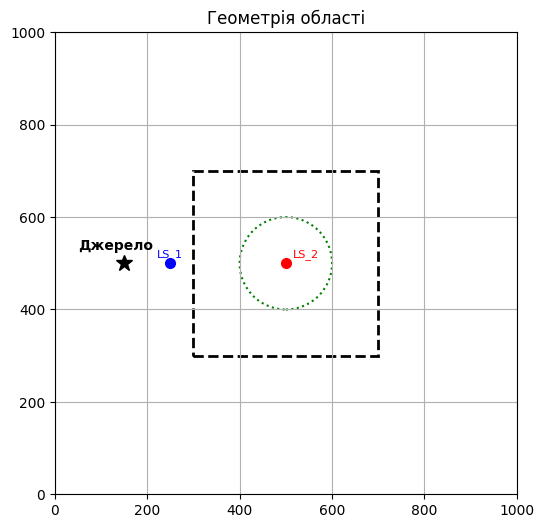

In [ ]:
# ВІЗУАЛІЗАЦІЯ ОБЛАСТІ

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

rect = plt.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    edgecolor='black',
    facecolor='none',
    lw=2,
    linestyle='--'
)
ax.add_patch(rect)

circle = plt.Circle(
    (Lx / 2, Ly / 2),
    100.0,
    edgecolor='green',
    facecolor='none',
    lw=1.5,
    linestyle=':'
)
ax.add_patch(circle)

# Джерело
sx, sy = x_fdm[source_i], y_fdm[source_j]
ax.plot(sx, sy, 'k*', markersize=12)
ax.text(sx - 100, sy + 30, 'Джерело', fontsize=10, weight='bold')

# Датчик МСР
ax.plot(rec_fdm_x, rec_fdm_y, 'bo', markersize=7)
ax.text(rec_fdm_x - 30, rec_fdm_y + 15, 'LS_1', color='blue', fontsize=8)

# Датчик МСЕ
ax.plot(rec_fem_x, rec_fem_y, 'ro', markersize=7)
ax.text(rec_fem_x + 15, rec_fem_y + 15, 'LS_2', color='red', fontsize=8)

ax.set_title("Геометрія області")
ax.set_aspect('equal')
ax.grid(True)

plt.show()

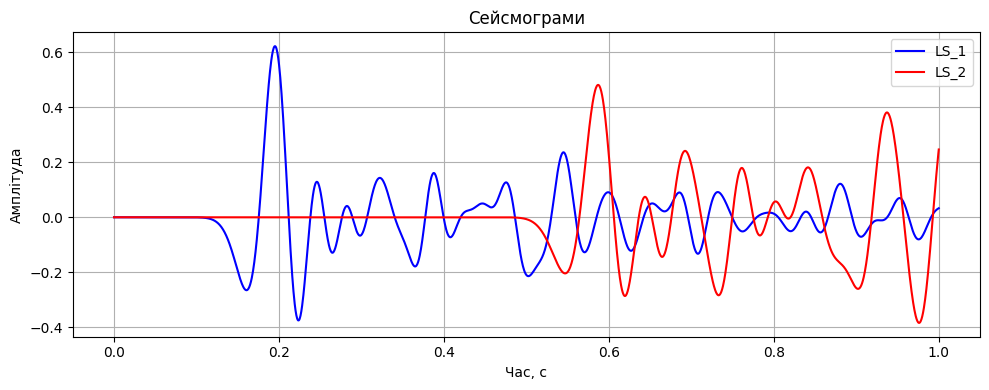

In [ ]:
# СЕЙСМОГРАМИ

plt.figure(figsize=(10, 4))
plt.plot(t_arr, seismo_fdm, label='LS_1', color='blue')
plt.plot(t_arr, seismo_fem, label='LS_2', color='red')
plt.title("Сейсмограми")
plt.xlabel("Час, с")
plt.ylabel("Амплітуда")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Запуск для c = 300.0
Запуск для c = 500.0
Запуск для c = 700.0


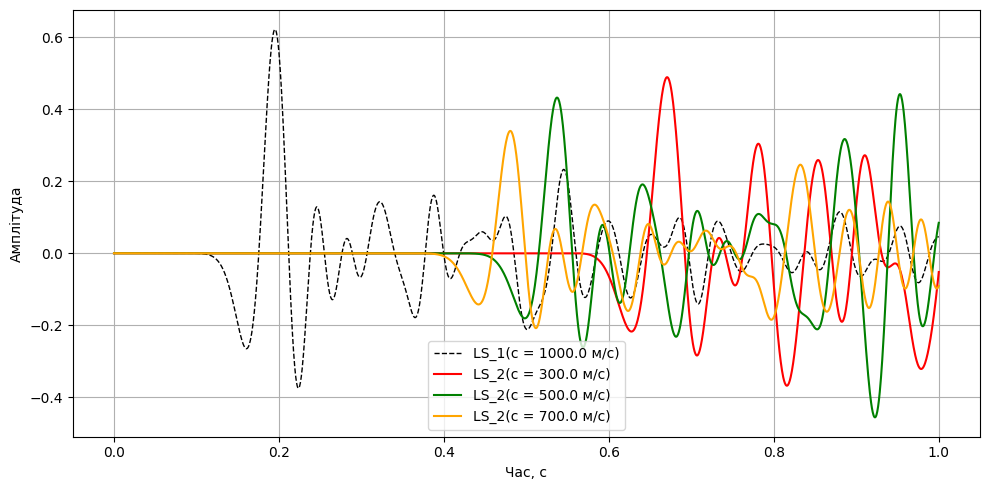

In [ ]:
# ПОРІВНЯННЯ СЕЙСМОГРАМ ДЛЯ РІЗНИХ ШВИДКОСТЕЙ

c_values = [300.0, 500.0, 700.0]  # швидкості в басейні

seismo_fem_all = []

for c_val in c_values:
    print(f"Запуск для c = {c_val}")

    fem_c_field = np.full(len(p2_elems), c_fem_bg)
    anomaly_mask = (fem_centers[:, 0] - Lx/2)**2 + (fem_centers[:, 1] - Ly/2)**2 < 100.0**2
    fem_c_field[anomaly_mask] = c_val

    M_lumped, K_mat = assemble_system(all_nodes, p2_elems, fem_c_field)
    inv_M = 1.0 / M_lumped

    u_curr_fdm = np.zeros((Nx, Ny))
    u_prev_fdm = np.zeros((Nx, Ny))
    u_curr_fem = np.zeros(len(all_nodes))
    u_prev_fem = np.zeros(len(all_nodes))

    seismo_fdm_tmp = []
    seismo_fem_tmp = []

    for n in range(n_steps):

        u_next_fdm_star = update_fdm(u_curr_fdm, u_prev_fdm, c_fdm, dx, dy, dt)
        u_next_fdm_star[source_i, source_j] += dt**2 * source_vals[n]

        Ku = K_mat.dot(u_curr_fem)
        accel = -Ku * inv_M
        u_next_fem_star = 2.0 * u_curr_fem - u_prev_fem + dt**2 * accel

        u_fem_at_fdm = P_fem_to_fdm.dot(u_next_fem_star).reshape(Nx, Ny)
        u_fdm_at_fem = interpolate_fdm_to_fem(u_next_fdm_star)

        u_next_fdm = u_next_fdm_star.copy()
        u_next_fem = u_next_fem_star.copy()

        u_next_fdm[mask_fdd_fdm] = u_fem_at_fdm[mask_fdd_fdm]

        u_next_fdm[mask_avg_fdm] = (
            (1 - w_avg_fdm[mask_avg_fdm]) * u_next_fdm_star[mask_avg_fdm] +
            w_avg_fdm[mask_avg_fdm] * u_fem_at_fdm[mask_avg_fdm]
        )

        u_next_fem[mask_feb_fem] = u_fdm_at_fem[mask_feb_fem]

        u_next_fem[mask_avg_fem] = (
            w_avg_fem[mask_avg_fem] * u_next_fem_star[mask_avg_fem] +
            (1 - w_avg_fem[mask_avg_fem]) * u_fdm_at_fem[mask_avg_fem]
        )

        seismo_fdm_tmp.append(interp_fdm_at_point(u_next_fdm, rec_fdm_x, rec_fdm_y, dx, dy))

        if P_rec_fem is not None:
            seismo_fem_tmp.append(P_rec_fem @ u_next_fem)
        else:
            seismo_fem_tmp.append(0.0)

        u_prev_fdm[:] = u_curr_fdm[:]
        u_curr_fdm[:] = u_next_fdm[:]

        u_prev_fem[:] = u_curr_fem[:]
        u_curr_fem[:] = u_next_fem[:]

    seismo_fem_all.append(seismo_fem_tmp)


plt.figure(figsize=(10, 5))

plt.plot(t_arr, seismo_fdm_tmp, 'k--', label='LS_1(c = 1000.0 м/с)', linewidth=1)

colors = ['red', 'green', 'orange']

for i, c_val in enumerate(c_values):
    plt.plot(t_arr, seismo_fem_all[i], color=colors[i],
             label=f'LS_2(c = {c_val} м/с)')

#plt.title("Порівняння сейсмограм для різних швидкостей у басейні")
plt.xlabel("Час, с")
plt.ylabel("Амплітуда")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Розташування точок:
  Джерело: (500.0, 500.0) - всередині басейну
  LS_1   : (500.0, 200.0) - поза FEM-прямокутником
  LS_2   : (500.0, 800.0) - поза FEM-прямокутником


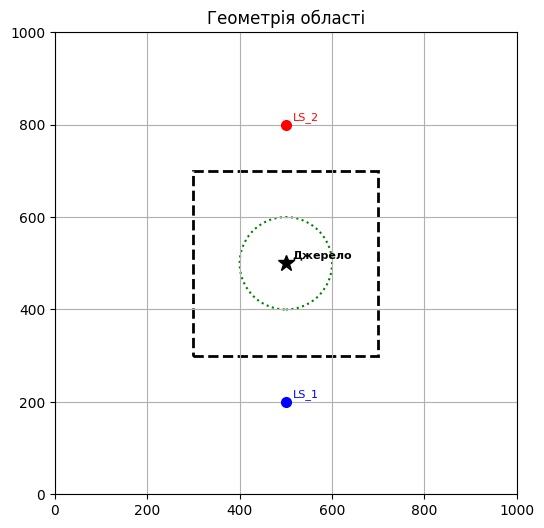

Швидкість у басейні: 700.0 м/с

Симуляція завершена за 3.39 с


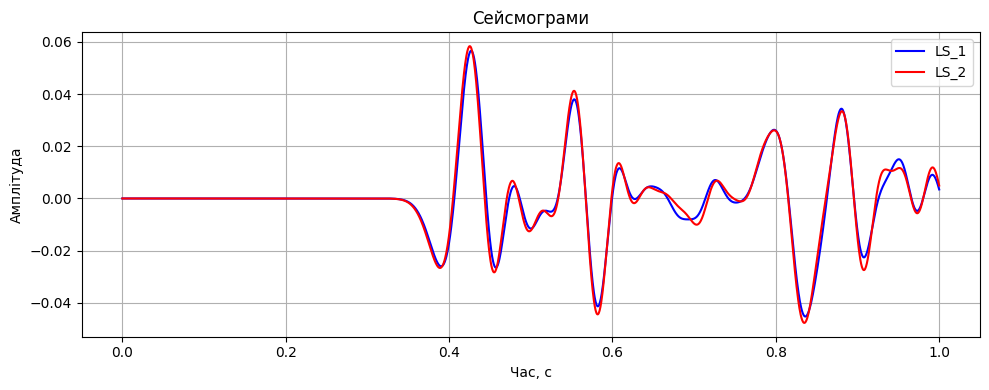

In [ ]:
# ЗМІНА РОЗТАШУВАННЯ ДЖЕРЕЛА І ТОЧОК СПОСТЕРЕЖЕННЯ

source_x, source_y = 500.0, 500.0
ls1_x, ls1_y       = 500.0, 200.0
ls2_x, ls2_y       = 500.0, 800.0

def check_point_in_domain(x, y, name):
    if not (0.0 <= x <= Lx and 0.0 <= y <= Ly):
        raise ValueError(f"{name} = ({x}, {y}) лежить поза розрахунковою областю.")

def point_in_rect(x, y, x0, x1, y0, y1):
    return (x0 <= x <= x1) and (y0 <= y <= y1)

def point_in_circle(x, y, cx, cy, r):
    return (x - cx)**2 + (y - cy)**2 <= r**2

def location_label(x, y):
    in_fem = point_in_rect(x, y, x_min, x_max, y_min, y_max)
    in_basin = point_in_circle(x, y, Lx/2, Ly/2, 100.0)
    if in_basin:
        return "всередині басейну"
    elif in_fem:
        return "у FEM-прямокутнику, але поза басейном"
    else:
        return "поза FEM-прямокутником"

def interp_on_grid(field, x, y, dx, dy):
    i0 = min(max(int(np.floor(x / dx)), 0), field.shape[0] - 2)
    j0 = min(max(int(np.floor(y / dy)), 0), field.shape[1] - 2)
    wx = x / dx - i0
    wy = y / dy - j0
    return (
        (1 - wx) * (1 - wy) * field[i0,     j0    ] +
        wx       * (1 - wy) * field[i0 + 1, j0    ] +
        (1 - wx) * wy       * field[i0,     j0 + 1] +
        wx       * wy       * field[i0 + 1, j0 + 1]
    )

def add_source_to_fdm_bilinear(u_field, x, y, amp, dx, dy):
    i0 = min(max(int(np.floor(x / dx)), 0), u_field.shape[0] - 2)
    j0 = min(max(int(np.floor(y / dy)), 0), u_field.shape[1] - 2)
    wx = x / dx - i0
    wy = y / dy - j0

    u_field[i0,     j0    ] += amp * (1 - wx) * (1 - wy)
    u_field[i0 + 1, j0    ] += amp * wx       * (1 - wy)
    u_field[i0,     j0 + 1] += amp * (1 - wx) * wy
    u_field[i0 + 1, j0 + 1] += amp * wx       * wy

def build_hybrid_field(u_fdm, u_fem):
    u_fem_on_fdm = P_fem_to_fdm.dot(u_fem).reshape(Nx, Ny)
    full_field = u_fdm.copy()
    full_field[mask_inside_fem_fdm] = u_fem_on_fdm[mask_inside_fem_fdm]
    return full_field

check_point_in_domain(source_x, source_y, "Джерело")
check_point_in_domain(ls1_x, ls1_y, "LS_1")
check_point_in_domain(ls2_x, ls2_y, "LS_2")

print("Розташування точок:")
print(f"  Джерело: ({source_x:.1f}, {source_y:.1f}) - {location_label(source_x, source_y)}")
print(f"  LS_1   : ({ls1_x:.1f}, {ls1_y:.1f}) - {location_label(ls1_x, ls1_y)}")
print(f"  LS_2   : ({ls2_x:.1f}, {ls2_y:.1f}) - {location_label(ls2_x, ls2_y)}")

source_in_fem = point_in_rect(source_x, source_y, x_min, x_max, y_min, y_max)

P_source_fem = None
if source_in_fem:
    P_source_fem = build_fem_point_projector(source_x, source_y)
    if P_source_fem is None:
        raise RuntimeError("Не вдалося побудувати FEM-проєктор.")

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(0, Lx)
ax.set_ylim(0, Ly)

rect = plt.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    edgecolor='black',
    facecolor='none',
    lw=2,
    linestyle='--'
)
ax.add_patch(rect)

circle = plt.Circle(
    (Lx / 2, Ly / 2),
    100.0,
    edgecolor='green',
    facecolor='none',
    lw=1.5,
    linestyle=':'
)
ax.add_patch(circle)

ax.plot(source_x, source_y, 'k*', markersize=12)
ax.text(source_x + 15, source_y + 10, 'Джерело', fontsize=8, weight='bold')

ax.plot(ls1_x, ls1_y, 'bo', markersize=7)
ax.text(ls1_x + 15, ls1_y + 10, 'LS_1', color='blue', fontsize=8)

ax.plot(ls2_x, ls2_y, 'ro', markersize=7)
ax.text(ls2_x + 15, ls2_y + 10, 'LS_2', color='red', fontsize=8)

ax.set_title("Геометрія області")
ax.set_aspect('equal')
ax.grid(True)
plt.show()

u_curr_fdm = np.zeros((Nx, Ny), dtype=float)
u_prev_fdm = np.zeros((Nx, Ny), dtype=float)

u_curr_fem = np.zeros(len(all_nodes), dtype=float)
u_prev_fem = np.zeros(len(all_nodes), dtype=float)

seismo_ls1 = []
seismo_ls2 = []
frames_custom = []


c_outside = 1000.0
c_anomaly = 700.0

fem_c_field = np.full(len(p2_elems), c_outside)

anomaly_mask = (
    (fem_centers[:, 0] - Lx/2)**2 +
    (fem_centers[:, 1] - Ly/2)**2
) < 100.0**2

fem_c_field[anomaly_mask] = c_anomaly

M_lumped, K_mat = assemble_system(all_nodes, p2_elems, fem_c_field)
inv_M = 1.0 / M_lumped

print(f"Швидкість у басейні: {c_anomaly} м/с")

start_t = time.time()

for n in range(n_steps):
    u_next_fdm_star = update_fdm(u_curr_fdm, u_prev_fdm, c_fdm, dx, dy, dt)

    if not source_in_fem:
        add_source_to_fdm_bilinear(
            u_next_fdm_star,
            source_x,
            source_y,
            dt**2 * source_vals[n],
            dx,
            dy
        )

    Ku = K_mat.dot(u_curr_fem)
    accel = -Ku * inv_M
    u_next_fem_star = 2.0 * u_curr_fem - u_prev_fem + dt**2 * accel

    if source_in_fem and (P_source_fem is not None):
        u_next_fem_star += dt**2 * source_vals[n] * P_source_fem

    u_fem_at_fdm = P_fem_to_fdm.dot(u_next_fem_star).reshape(Nx, Ny)

    u_fdm_at_fem = interpolate_fdm_to_fem(u_next_fdm_star)

    u_next_fdm = u_next_fdm_star.copy()
    u_next_fem = u_next_fem_star.copy()

    u_next_fdm[mask_fdd_fdm] = u_fem_at_fdm[mask_fdd_fdm]

    u_next_fdm[mask_avg_fdm] = (
        (1.0 - w_avg_fdm[mask_avg_fdm]) * u_next_fdm_star[mask_avg_fdm] +
        w_avg_fdm[mask_avg_fdm]         * u_fem_at_fdm[mask_avg_fdm]
    )

    u_next_fem[mask_feb_fem] = u_fdm_at_fem[mask_feb_fem]

    u_next_fem[mask_avg_fem] = (
        w_avg_fem[mask_avg_fem]         * u_next_fem_star[mask_avg_fem] +
        (1.0 - w_avg_fem[mask_avg_fem]) * u_fdm_at_fem[mask_avg_fem]
    )

    hybrid_field = build_hybrid_field(u_next_fdm, u_next_fem)

    seismo_ls1.append(interp_on_grid(hybrid_field, ls1_x, ls1_y, dx, dy))
    seismo_ls2.append(interp_on_grid(hybrid_field, ls2_x, ls2_y, dx, dy))

    u_prev_fdm[:] = u_curr_fdm[:]
    u_curr_fdm[:] = u_next_fdm[:]

    u_prev_fem[:] = u_curr_fem[:]
    u_curr_fem[:] = u_next_fem[:]

    if n in [int(n_steps * 0.35), int(n_steps * 0.65), int(n_steps * 0.95)]:
        frames_custom.append((n * dt, hybrid_field.copy()))

elapsed = time.time() - start_t
print()
print(f"Симуляція завершена за {elapsed:.2f} с")

plt.figure(figsize=(10, 4))
plt.plot(t_arr, seismo_ls1, label='LS_1', color='blue')
plt.plot(t_arr, seismo_ls2, label='LS_2', color='red')
plt.title("Сейсмограми")
plt.xlabel("Час, с")
plt.ylabel("Амплітуда")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

МСЕ: 40583 вузлів.
Комбінований метод, МСЕ: 17673 вузлів.

Обчислення для d1 (Ellipse)
  МСЕ: 7.40 с
  Комбінований: 14.67 с

Обчислення для d2 (Rounded)
  МСЕ: 7.72 с
  Комбінований: 13.30 с

Обчислення для d3 (Star)
  МСЕ: 6.51 с
  Комбінований: 11.99 с


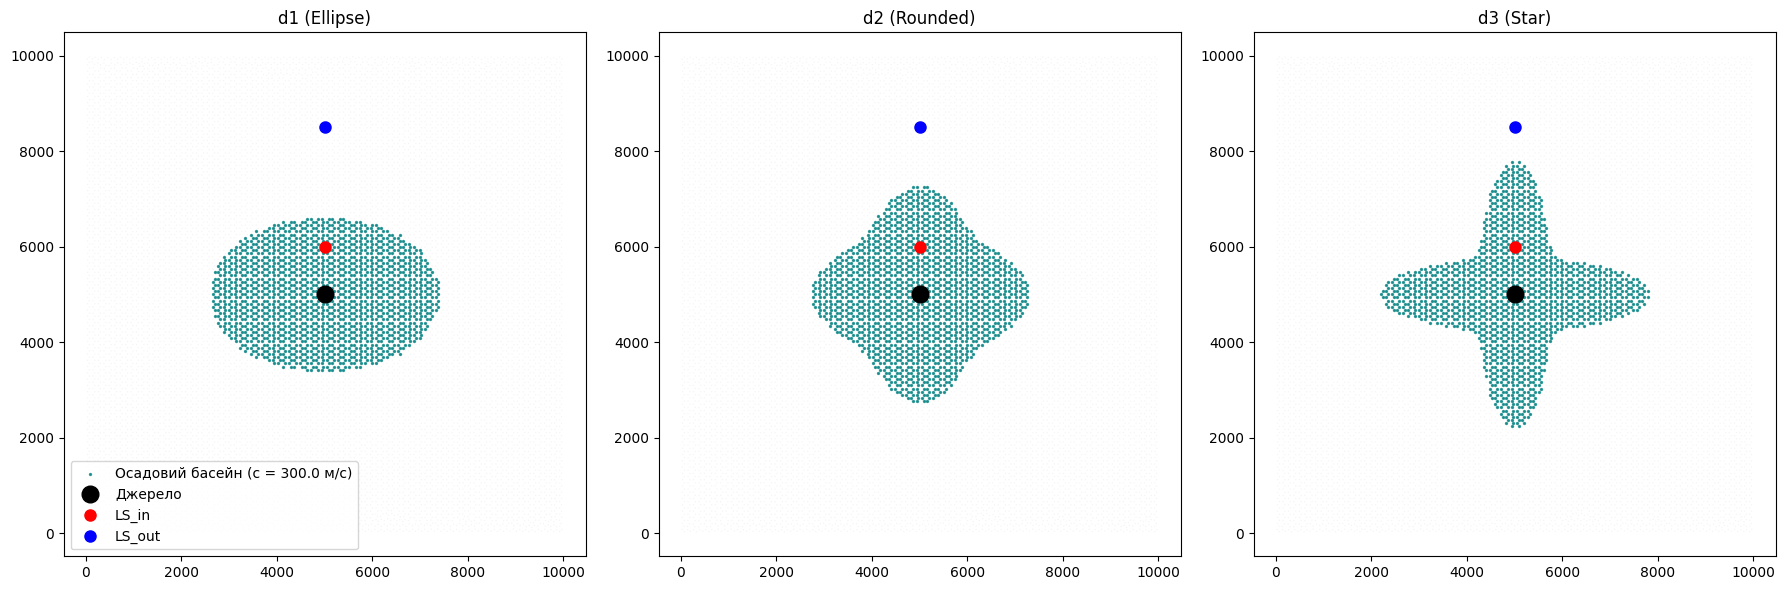

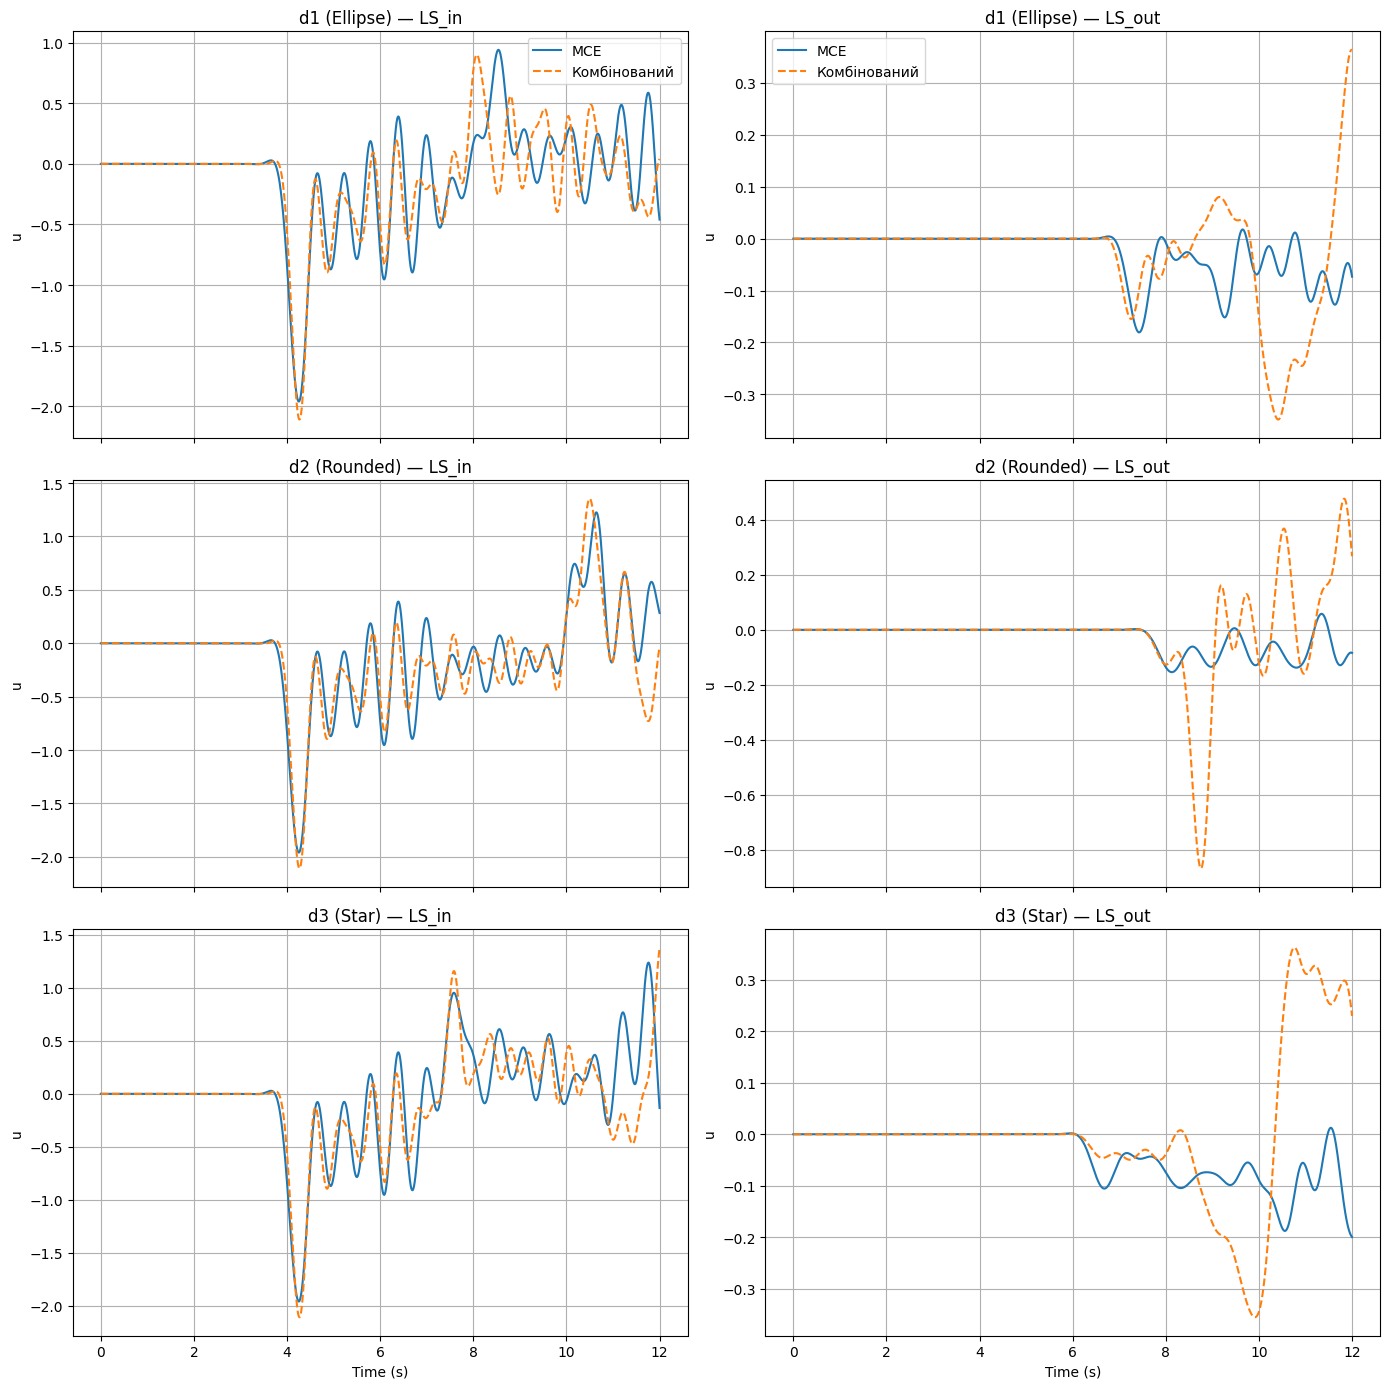

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree
from numba import njit
import time

try:
    import gmsh
except ImportError:
    raise ImportError("Не знайдено gmsh.")

def generate_fem_mesh(x0, x1, y0, y1, h):
    if hasattr(gmsh, "isInitialized") and gmsh.isInitialized():
        gmsh.finalize()

    gmsh.initialize()
    gmsh.model.add("fem_rect")

    p1 = gmsh.model.geo.addPoint(x0, y0, 0, h)
    p2 = gmsh.model.geo.addPoint(x1, y0, 0, h)
    p3 = gmsh.model.geo.addPoint(x1, y1, 0, h)
    p4 = gmsh.model.geo.addPoint(x0, y1, 0, h)

    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addLine(p4, p1)

    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    gmsh.model.geo.addPlaneSurface([loop])

    nx_pts = int((x1 - x0) / h) + 1
    ny_pts = int((y1 - y0) / h) + 1
    gmsh.model.geo.mesh.setTransfiniteCurve(l1, nx_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l2, ny_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l3, nx_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l4, ny_pts)

    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)

    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

    elem_types, elem_tags, elem_node_tags = gmsh.model.mesh.getElements(dim=2)
    elems = None
    for et, tags, nodes_list in zip(elem_types, elem_tags, elem_node_tags):
        if et == 2:
            elems = np.array(nodes_list, dtype=int).reshape(-1, 3)
            break

    if elems is None:
        gmsh.finalize()
        raise RuntimeError("Не знайдено трикутних елементів типу 2.")

    tag_to_idx = {int(tag): i for i, tag in enumerate(node_tags)}
    elems_idx = np.vectorize(tag_to_idx.get)(elems)

    gmsh.finalize()
    return nodes, elems_idx


def create_p2_tilde_mesh(base_nodes, base_elems):
    edge_to_mid = {}
    all_nodes = list(base_nodes.copy())
    p2_elems = np.zeros((len(base_elems), 7), dtype=int)
    centers = []

    for i, tri in enumerate(base_elems):
        v0, v1, v2 = int(tri[0]), int(tri[1]), int(tri[2])
        p2_elems[i, 0:3] = [v0, v1, v2]

        edges = [(v0, v1), (v1, v2), (v2, v0)]
        for j, e in enumerate(edges):
            key = tuple(sorted(e))
            if key not in edge_to_mid:
                mid_coord = 0.5 * (base_nodes[key[0]] + base_nodes[key[1]])
                edge_to_mid[key] = len(all_nodes)
                all_nodes.append(mid_coord)
            p2_elems[i, 3 + j] = edge_to_mid[key]

        center = np.mean(base_nodes[[v0, v1, v2]], axis=0)
        centers.append(center)
        p2_elems[i, 6] = len(all_nodes)
        all_nodes.append(center)

    return np.array(all_nodes), p2_elems, np.array(centers)


def p2_tilde_shape_functions(l1, l2, l3):
    l1l2l3 = l1 * l2 * l3
    N = np.zeros(7, dtype=float)
    N[0] = l1 * (2.0 * l1 - 1.0) + 3.0 * l1l2l3
    N[1] = l2 * (2.0 * l2 - 1.0) + 3.0 * l1l2l3
    N[2] = l3 * (2.0 * l3 - 1.0) + 3.0 * l1l2l3
    N[3] = 4.0 * l1 * l2 - 12.0 * l1l2l3
    N[4] = 4.0 * l2 * l3 - 12.0 * l1l2l3
    N[5] = 4.0 * l3 * l1 - 12.0 * l1l2l3
    N[6] = 27.0 * l1l2l3
    return N


def get_P2_tilde_grad_shape_functions():
    grad_N = [
        lambda l: np.array([4*l[0]-1+3*l[1]*l[2], 3*l[0]*l[2], 3*l[0]*l[1]]),
        lambda l: np.array([3*l[1]*l[2], 4*l[1]-1+3*l[0]*l[2], 3*l[0]*l[1]]),
        lambda l: np.array([3*l[1]*l[2], 3*l[0]*l[2], 4*l[2]-1+3*l[0]*l[1]]),
        lambda l: np.array([4*l[1]-12*l[1]*l[2], 4*l[0]-12*l[0]*l[2], -12*l[0]*l[1]]),
        lambda l: np.array([-12*l[1]*l[2], 4*l[2]-12*l[0]*l[2], 4*l[1]-12*l[0]*l[1]]),
        lambda l: np.array([4*l[2]-12*l[1]*l[2], -12*l[0]*l[2], 4*l[0]-12*l[0]*l[1]]),
        lambda l: np.array([27*l[1]*l[2], 27*l[0]*l[2], 27*l[0]*l[1]])
    ]
    return grad_N


def gauss_quadrature_triangle_p4():
    w1, w2 = 0.223381589678011, 0.109951743655322
    a1, a2 = 0.445948490915965, 0.091576213509771
    pts = np.array([
        [a1, a1],
        [a1, 1 - 2*a1],
        [1 - 2*a1, a1],
        [a2, a2],
        [a2, 1 - 2*a2],
        [1 - 2*a2, a2]
    ])
    wts = np.array([w1, w1, w1, w2, w2, w2])
    return pts, wts


def mass_lumping_weights():
    return np.array([1/20, 1/20, 1/20, 2/15, 2/15, 2/15, 9/20], dtype=float)


def assemble_system(nodes, elems, c_field):
    n_nodes = len(nodes)
    M_diag = np.zeros(n_nodes, dtype=float)

    rows_A, cols_A, data_A = [], [], []
    lump_w = mass_lumping_weights()
    grad_N_funcs = get_P2_tilde_grad_shape_functions()
    quad_pts, quad_wts = gauss_quadrature_triangle_p4()

    for k in range(len(elems)):
        el_nodes = elems[k]
        verts = nodes[el_nodes[0:3]]

        area = 0.5 * abs(
            (verts[1, 0] - verts[0, 0]) * (verts[2, 1] - verts[0, 1]) -
            (verts[1, 1] - verts[0, 1]) * (verts[2, 0] - verts[0, 0])
        )

        for i in range(7):
            M_diag[el_nodes[i]] += area * lump_w[i]

        b = np.array([
            verts[1, 1] - verts[2, 1],
            verts[2, 1] - verts[0, 1],
            verts[0, 1] - verts[1, 1]
        ]) / (2 * area)

        c = np.array([
            verts[2, 0] - verts[1, 0],
            verts[0, 0] - verts[2, 0],
            verts[1, 0] - verts[0, 0]
        ]) / (2 * area)

        grad_lambda = np.array([
            [b[0], c[0]],
            [b[1], c[1]],
            [b[2], c[2]]
        ])

        c_sq = c_field[k]**2
        local_K = np.zeros((7, 7), dtype=float)

        for q in range(len(quad_wts)):
            l1, l2 = quad_pts[q]
            lam = np.array([1 - l1 - l2, l1, l2], dtype=float)
            dNi_dlam = [gn(lam) for gn in grad_N_funcs]

            dNi_dx = np.zeros(7)
            dNi_dy = np.zeros(7)
            for i in range(7):
                grad_xy = dNi_dlam[i] @ grad_lambda
                dNi_dx[i] = grad_xy[0]
                dNi_dy[i] = grad_xy[1]

            factor = quad_wts[q] * area * c_sq
            for i in range(7):
                for j in range(7):
                    local_K[i, j] += (dNi_dx[i]*dNi_dx[j] + dNi_dy[i]*dNi_dy[j]) * factor

        for i in range(7):
            for j in range(7):
                rows_A.append(el_nodes[i])
                cols_A.append(el_nodes[j])
                data_A.append(local_K[i, j])

    A_mat = coo_matrix((data_A, (rows_A, cols_A)), shape=(n_nodes, n_nodes)).tocsr()
    return M_diag, A_mat


def calculate_stable_dt(nodes, elems, c_max, cfl_factor=0.1):
    tri_verts_idx = elems[:, 0:3]
    v0 = nodes[tri_verts_idx[:, 1]] - nodes[tri_verts_idx[:, 0]]
    v1 = nodes[tri_verts_idx[:, 2]] - nodes[tri_verts_idx[:, 1]]
    v2 = nodes[tri_verts_idx[:, 0]] - nodes[tri_verts_idx[:, 2]]
    h_min_global = np.min([
        np.min(np.linalg.norm(v0, axis=1)),
        np.min(np.linalg.norm(v1, axis=1)),
        np.min(np.linalg.norm(v2, axis=1))
    ])
    return cfl_factor * (h_min_global / 2.0) / c_max

def get_basin_radius_polar(theta, n, e, scale=1000.0):
    numerator = 2.0 * (1.0 - e**2)
    denominator = 1.0 - e * np.cos(n * theta)
    return scale * (numerator / denominator)


def set_velocity_field_for_elems(nodes, elems, n, e, c_in, c_out, center):
    elem_centers = np.mean(nodes[elems[:, 0:3]], axis=1)
    dx = elem_centers[:, 0] - center[0]
    dy = elem_centers[:, 1] - center[1]
    r_elem = np.sqrt(dx**2 + dy**2)
    theta_elem = np.arctan2(dy, dx)

    r_boundary = get_basin_radius_polar(theta_elem, n, e, scale=1000.0)

    c_field = np.ones(len(elems)) * c_out
    mask_inside = r_elem < r_boundary
    c_field[mask_inside] = c_in

    return c_field, mask_inside, elem_centers


def build_velocity_grid(x_arr, y_arr, n, e, c_in, c_out, center):
    X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')
    dx = X - center[0]
    dy = Y - center[1]
    r = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    r_boundary = get_basin_radius_polar(theta, n, e, scale=1000.0)

    c_grid = np.ones_like(X) * c_out
    c_grid[r < r_boundary] = c_in
    return c_grid

def source_func(t, t0=1.0, tau=0.15):
    if t < 0:
        return 0.0
    val = (t - t0) / (tau**2) * np.exp(-(t - t0) / tau)
    return val if val > -100 else 0.0


def interp_on_grid(field, x, y, dx, dy):
    i0 = min(max(int(np.floor(x / dx)), 0), field.shape[0] - 2)
    j0 = min(max(int(np.floor(y / dy)), 0), field.shape[1] - 2)
    wx = x / dx - i0
    wy = y / dy - j0
    return (
        (1 - wx) * (1 - wy) * field[i0,     j0    ] +
        wx       * (1 - wy) * field[i0 + 1, j0    ] +
        (1 - wx) * wy       * field[i0,     j0 + 1] +
        wx       * wy       * field[i0 + 1, j0 + 1]
    )


def add_source_to_grid_bilinear(u_field, x, y, amp, dx, dy):
    i0 = min(max(int(np.floor(x / dx)), 0), u_field.shape[0] - 2)
    j0 = min(max(int(np.floor(y / dy)), 0), u_field.shape[1] - 2)
    wx = x / dx - i0
    wy = y / dy - j0

    u_field[i0,     j0    ] += amp * (1 - wx) * (1 - wy)
    u_field[i0 + 1, j0    ] += amp * wx       * (1 - wy)
    u_field[i0,     j0 + 1] += amp * (1 - wx) * wy
    u_field[i0 + 1, j0 + 1] += amp * wx       * wy

@njit
def update_fdm_variable_c(u, u_old, c_grid, dx, dy, dt):
    nx, ny = u.shape
    u_new = np.zeros_like(u)
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            lap = ((u[i + 1, j] - 2.0*u[i, j] + u[i - 1, j]) / dx**2 +
                   (u[i, j + 1] - 2.0*u[i, j] + u[i, j - 1]) / dy**2)
            u_new[i, j] = 2.0*u[i, j] - u_old[i, j] + dt**2 * (c_grid[i, j]**2) * lap
    return u_new

def build_exact_fem_to_grid_matrix(base_nodes, base_elems, p2_elems, x_arr, y_arr, n_fem_nodes):
    triang = mtri.Triangulation(base_nodes[:, 0], base_nodes[:, 1], base_elems)
    finder = triang.get_trifinder()

    rows, cols, data = [], [], []
    Nx_loc = len(x_arr)
    Ny_loc = len(y_arr)

    for i in range(Nx_loc):
        for j in range(Ny_loc):
            x, y = x_arr[i], y_arr[j]
            tri_idx = finder(x, y)
            if tri_idx != -1:
                tri = base_elems[tri_idx]
                x1, y1 = base_nodes[tri[0]]
                x2, y2 = base_nodes[tri[1]]
                x3, y3 = base_nodes[tri[2]]

                detT = (y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3)
                l1 = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / detT
                l2 = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / detT
                l3 = 1.0 - l1 - l2

                N = p2_tilde_shape_functions(l1, l2, l3)
                fem_nodes_idx = p2_elems[tri_idx]
                flat_idx = i * Ny_loc + j

                for k in range(7):
                    rows.append(flat_idx)
                    cols.append(fem_nodes_idx[k])
                    data.append(N[k])

    P = coo_matrix((data, (rows, cols)), shape=(Nx_loc * Ny_loc, n_fem_nodes)).tocsr()
    return P, triang, finder

# ПАРАМЕТРИ ЗАДАЧІ
L_domain = 10000.0
c_out = 1700.0
c_in = 300.0

center_pos = (5000.0, 5000.0)
source_pos = (5000.0, 5000.0)
rec_in_pos = (5000.0, 6000.0)
rec_out_pos = (5000.0, 8500.0)

shapes = {
    'd1 (Ellipse)': {'n': 2, 'e': 0.2},
    'd2 (Rounded)': {'n': 4, 'e': 0.15},
    'd3 (Star)':    {'n': 4, 'e': 0.4}
}

T_max = 12.0

# МСЕ
mesh_h_full = 130.0
base_nodes_full, base_elems_full = generate_fem_mesh(0.0, L_domain, 0.0, L_domain, mesh_h_full)
all_nodes_full, p2_elems_full, fem_centers_full = create_p2_tilde_mesh(base_nodes_full, base_elems_full)
n_nodes_full = len(all_nodes_full)
print(f"МСЕ: {n_nodes_full} вузлів.")

dt_full = calculate_stable_dt(all_nodes_full, p2_elems_full, c_out, cfl_factor=0.1)

tree_full = KDTree(all_nodes_full)
_, idx_S_full = tree_full.query(source_pos)
_, idx_Lin_full = tree_full.query(rec_in_pos)
_, idx_Lout_full = tree_full.query(rec_out_pos)

# КОМБІНОВАНИЙ МЕТОД

Nx_h, Ny_h = 101, 101
dx_h = L_domain / (Nx_h - 1)
dy_h = L_domain / (Ny_h - 1)
x_fdm_h = np.linspace(0.0, L_domain, Nx_h)
y_fdm_h = np.linspace(0.0, L_domain, Ny_h)

x_min_h, x_max_h = 2500.0, 7500.0
y_min_h, y_max_h = 2500.0, 7500.0

base_nodes_h, base_elems_h = generate_fem_mesh(x_min_h, x_max_h, y_min_h, y_max_h, dx_h)
all_nodes_h, p2_elems_h, fem_centers_h = create_p2_tilde_mesh(base_nodes_h, base_elems_h)
n_nodes_h = len(all_nodes_h)
print(f"Комбінований метод, МСЕ: {n_nodes_h} вузлів.")

dt_hyb = calculate_stable_dt(all_nodes_h, p2_elems_h, c_out, cfl_factor=0.1)

dt = min(dt_full, dt_hyb, 0.05 * dx_h / c_out)
n_steps = int(T_max / dt)
t_arr = np.linspace(0.0, T_max, n_steps)
source_vals = np.array([source_func(t) * 1e5 for t in t_arr])

P_fem_to_fdm_h, triang_h, finder_h = build_exact_fem_to_grid_matrix(
    base_nodes_h, base_elems_h, p2_elems_h, x_fdm_h, y_fdm_h, n_nodes_h
)

i0_arr_h = np.clip(np.floor(all_nodes_h[:, 0] / dx_h).astype(int), 0, Nx_h - 2)
j0_arr_h = np.clip(np.floor(all_nodes_h[:, 1] / dy_h).astype(int), 0, Ny_h - 2)
wx_arr_h = (all_nodes_h[:, 0] / dx_h) - i0_arr_h
wy_arr_h = (all_nodes_h[:, 1] / dy_h) - j0_arr_h

def interpolate_fdm_to_fem_h(u_fdm):
    return (
        (1 - wx_arr_h) * (1 - wy_arr_h) * u_fdm[i0_arr_h,     j0_arr_h    ] +
        wx_arr_h       * (1 - wy_arr_h) * u_fdm[i0_arr_h + 1, j0_arr_h    ] +
        (1 - wx_arr_h) * wy_arr_h       * u_fdm[i0_arr_h,     j0_arr_h + 1] +
        wx_arr_h       * wy_arr_h       * u_fdm[i0_arr_h + 1, j0_arr_h + 1]
    )

feb_width = 1.0 * dx_h
avg_width = 3.0 * dx_h
fdd_width = 1.0 * dx_h
transition_width = feb_width + avg_width + fdd_width

def inside_fem_rect_h(x, y):
    return (x_min_h <= x <= x_max_h) and (y_min_h <= y <= y_max_h)

def dist_to_fem_boundary_h(x, y):
    return min(x - x_min_h, x_max_h - x, y - y_min_h, y_max_h - y)

mask_inside_fem_fdm_h = np.zeros((Nx_h, Ny_h), dtype=bool)
mask_avg_fdm_h = np.zeros((Nx_h, Ny_h), dtype=bool)
mask_fdd_fdm_h = np.zeros((Nx_h, Ny_h), dtype=bool)
w_avg_fdm_h = np.zeros((Nx_h, Ny_h), dtype=float)

for i in range(Nx_h):
    for j in range(Ny_h):
        x, y = x_fdm_h[i], y_fdm_h[j]
        if inside_fem_rect_h(x, y):
            mask_inside_fem_fdm_h[i, j] = True
            d = dist_to_fem_boundary_h(x, y)
            if feb_width <= d < feb_width + avg_width:
                mask_avg_fdm_h[i, j] = True
                w_avg_fdm_h[i, j] = (d - feb_width) / avg_width
            elif feb_width + avg_width <= d < transition_width:
                mask_fdd_fdm_h[i, j] = True

mask_feb_fem_h = np.zeros(n_nodes_h, dtype=bool)
mask_avg_fem_h = np.zeros(n_nodes_h, dtype=bool)
w_avg_fem_h = np.zeros(n_nodes_h, dtype=float)

for k, (x, y) in enumerate(all_nodes_h):
    d = dist_to_fem_boundary_h(x, y)
    if d < feb_width:
        mask_feb_fem_h[k] = True
    elif feb_width <= d < feb_width + avg_width:
        mask_avg_fem_h[k] = True
        w_avg_fem_h[k] = (d - feb_width) / avg_width

tree_local = KDTree(all_nodes_h)
_, idx_S_local = tree_local.query(source_pos)

i_rec_in = int(round(rec_in_pos[0] / dx_h))
j_rec_in = int(round(rec_in_pos[1] / dy_h))
i_rec_out = int(round(rec_out_pos[0] / dx_h))
j_rec_out = int(round(rec_out_pos[1] / dy_h))

results = {}

for name, params in shapes.items():
    print(f"\nОбчислення для {name}")

    # МСЕ
    c_field_full, mask_full, centers_full = set_velocity_field_for_elems(
        all_nodes_full, p2_elems_full, params['n'], params['e'], c_in, c_out, center_pos
    )

    M_full, K_full = assemble_system(all_nodes_full, p2_elems_full, c_field_full)
    inv_M_full = 1.0 / M_full

    u_prev_full = np.zeros(n_nodes_full)
    u_curr_full = np.zeros(n_nodes_full)

    hist_full_in = []
    hist_full_out = []

    t0 = time.time()
    for n in range(n_steps):
        F_vec = np.zeros(n_nodes_full)
        F_vec[idx_S_full] = source_vals[n]

        Ku = K_full.dot(u_curr_full)
        accel = (F_vec - Ku) * inv_M_full
        u_next = 2.0 * u_curr_full - u_prev_full + (dt**2) * accel

        hist_full_in.append(u_next[idx_Lin_full])
        hist_full_out.append(u_next[idx_Lout_full])

        u_prev_full[:] = u_curr_full[:]
        u_curr_full[:] = u_next[:]

    fem_time = time.time() - t0

    # КОМБІНОВАНИЙ МЕТОД
    c_field_h, mask_h, centers_h = set_velocity_field_for_elems(
        all_nodes_h, p2_elems_h, params['n'], params['e'], c_in, c_out, center_pos
    )

    M_h, K_h = assemble_system(all_nodes_h, p2_elems_h, c_field_h)
    inv_M_h = 1.0 / M_h

    c_grid_h = build_velocity_grid(x_fdm_h, y_fdm_h, params['n'], params['e'], c_in, c_out, center_pos)

    u_prev_fdm = np.zeros((Nx_h, Ny_h))
    u_curr_fdm = np.zeros((Nx_h, Ny_h))

    u_prev_fem = np.zeros(n_nodes_h)
    u_curr_fem = np.zeros(n_nodes_h)

    hist_hyb_in = []
    hist_hyb_out = []

    source_inside_local_fem = inside_fem_rect_h(source_pos[0], source_pos[1])

    t1 = time.time()
    for n in range(n_steps):
        u_next_fdm_star = update_fdm_variable_c(u_curr_fdm, u_prev_fdm, c_grid_h, dx_h, dy_h, dt)

        if not source_inside_local_fem:
            add_source_to_grid_bilinear(
                u_next_fdm_star,
                source_pos[0], source_pos[1],
                dt**2 * source_vals[n],
                dx_h, dy_h
            )

        Ku_h = K_h.dot(u_curr_fem)
        accel_h = -Ku_h * inv_M_h
        u_next_fem_star = 2.0 * u_curr_fem - u_prev_fem + dt**2 * accel_h

        if source_inside_local_fem:
            u_next_fem_star[idx_S_local] += source_vals[n] * inv_M_h[idx_S_local] * dt**2

        u_fem_at_fdm = P_fem_to_fdm_h.dot(u_next_fem_star).reshape(Nx_h, Ny_h)
        u_fdm_at_fem = interpolate_fdm_to_fem_h(u_next_fdm_star)

        u_next_fdm = u_next_fdm_star.copy()
        u_next_fem = u_next_fem_star.copy()

        u_next_fdm[mask_fdd_fdm_h] = u_fem_at_fdm[mask_fdd_fdm_h]

        u_next_fdm[mask_avg_fdm_h] = (
            (1.0 - w_avg_fdm_h[mask_avg_fdm_h]) * u_next_fdm_star[mask_avg_fdm_h] +
            w_avg_fdm_h[mask_avg_fdm_h]         * u_fem_at_fdm[mask_avg_fdm_h]
        )

        u_next_fem[mask_feb_fem_h] = u_fdm_at_fem[mask_feb_fem_h]

        u_next_fem[mask_avg_fem_h] = (
            w_avg_fem_h[mask_avg_fem_h]         * u_next_fem_star[mask_avg_fem_h] +
            (1.0 - w_avg_fem_h[mask_avg_fem_h]) * u_fdm_at_fem[mask_avg_fem_h]
        )

        hybrid_field = u_next_fdm.copy()
        hybrid_field[mask_inside_fem_fdm_h] = u_fem_at_fdm[mask_inside_fem_fdm_h]

        hist_hyb_in.append(hybrid_field[i_rec_in, j_rec_in])
        hist_hyb_out.append(hybrid_field[i_rec_out, j_rec_out])

        u_prev_fdm[:] = u_curr_fdm[:]
        u_curr_fdm[:] = u_next_fdm[:]

        u_prev_fem[:] = u_curr_fem[:]
        u_curr_fem[:] = u_next_fem[:]

    hyb_time = time.time() - t1

    print(f"  МСЕ: {fem_time:.2f} с")
    print(f"  Комбінований: {hyb_time:.2f} с")

    results[name] = {
        'centers': centers_full,
        'mask': mask_full,
        'fem_in': hist_full_in,
        'fem_out': hist_full_out,
        'hyb_in': hist_hyb_in,
        'hyb_out': hist_hyb_out
    }

plt.figure(figsize=(18, 6))
for i, (name, data) in enumerate(results.items()):
    plt.subplot(1, 3, i + 1)

    centers = data['centers']
    mask = data['mask']

    plt.scatter(centers[~mask, 0], centers[~mask, 1], c='whitesmoke', s=1, edgecolor='none')
    plt.scatter(centers[mask, 0], centers[mask, 1], c='teal', s=2, alpha=0.75, label='Осадовий басейн (c = 300.0 м/с)')

    plt.plot(source_pos[0], source_pos[1], 'ko', markersize=12, label='Джерело')
    plt.plot(rec_in_pos[0], rec_in_pos[1], 'ro', markersize=8, label='LS_in')
    plt.plot(rec_out_pos[0], rec_out_pos[1], 'bo', markersize=8, label='LS_out')

    plt.title(name)
    plt.axis('equal')
    if i == 0:
        plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)

for row, (name, data) in enumerate(results.items()):
    ax = axes[row, 0]
    ax.plot(t_arr, data['fem_in'], label='МСЕ', linewidth=1.5)
    ax.plot(t_arr, data['hyb_in'], label='Комбінований', linewidth=1.5, linestyle='--')
    ax.set_title(f"{name} — LS_in")
    ax.set_ylabel("u")
    ax.grid(True)
    if row == 0:
        ax.legend()

    ax = axes[row, 1]
    ax.plot(t_arr, data['fem_out'], label='МСЕ', linewidth=1.5)
    ax.plot(t_arr, data['hyb_out'], label='Комбінований', linewidth=1.5, linestyle='--')
    ax.set_title(f"{name} — LS_out")
    ax.set_ylabel("u")
    ax.grid(True)
    if row == 0:
        ax.legend()

axes[2, 0].set_xlabel("Time (s)")
axes[2, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

МСЕ: 40583 вузлів.
Комбінований метод, МСЕ: 11835 вузлів.

Обчислення для d1 (Ellipse)
  МСЕ: 6.07 с
  Комбінований: 7.47 с

Обчислення для d2 (Rounded)
  МСЕ: 12.40 с
  Комбінований: 6.14 с

Обчислення для d3 (Star)
  МСЕ: 6.13 с
  Комбінований: 6.66 с


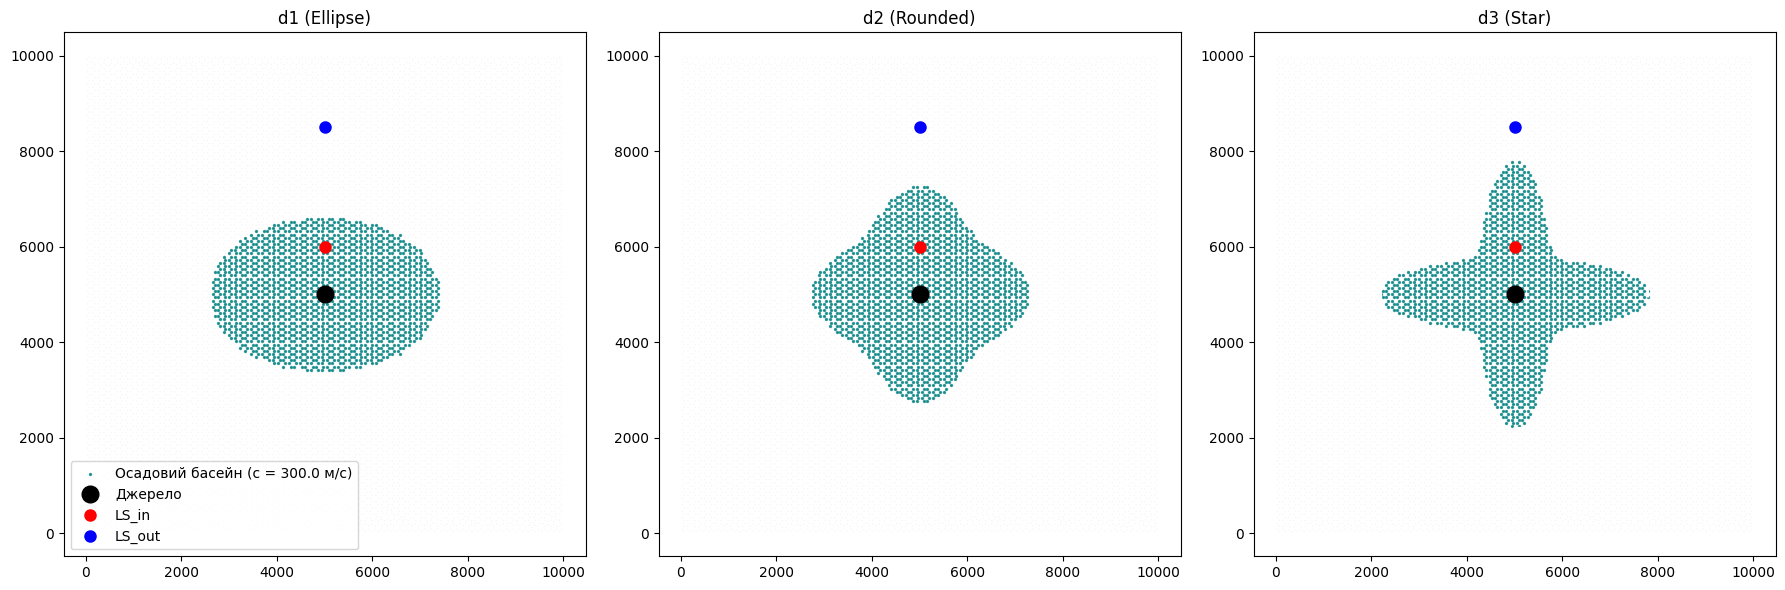

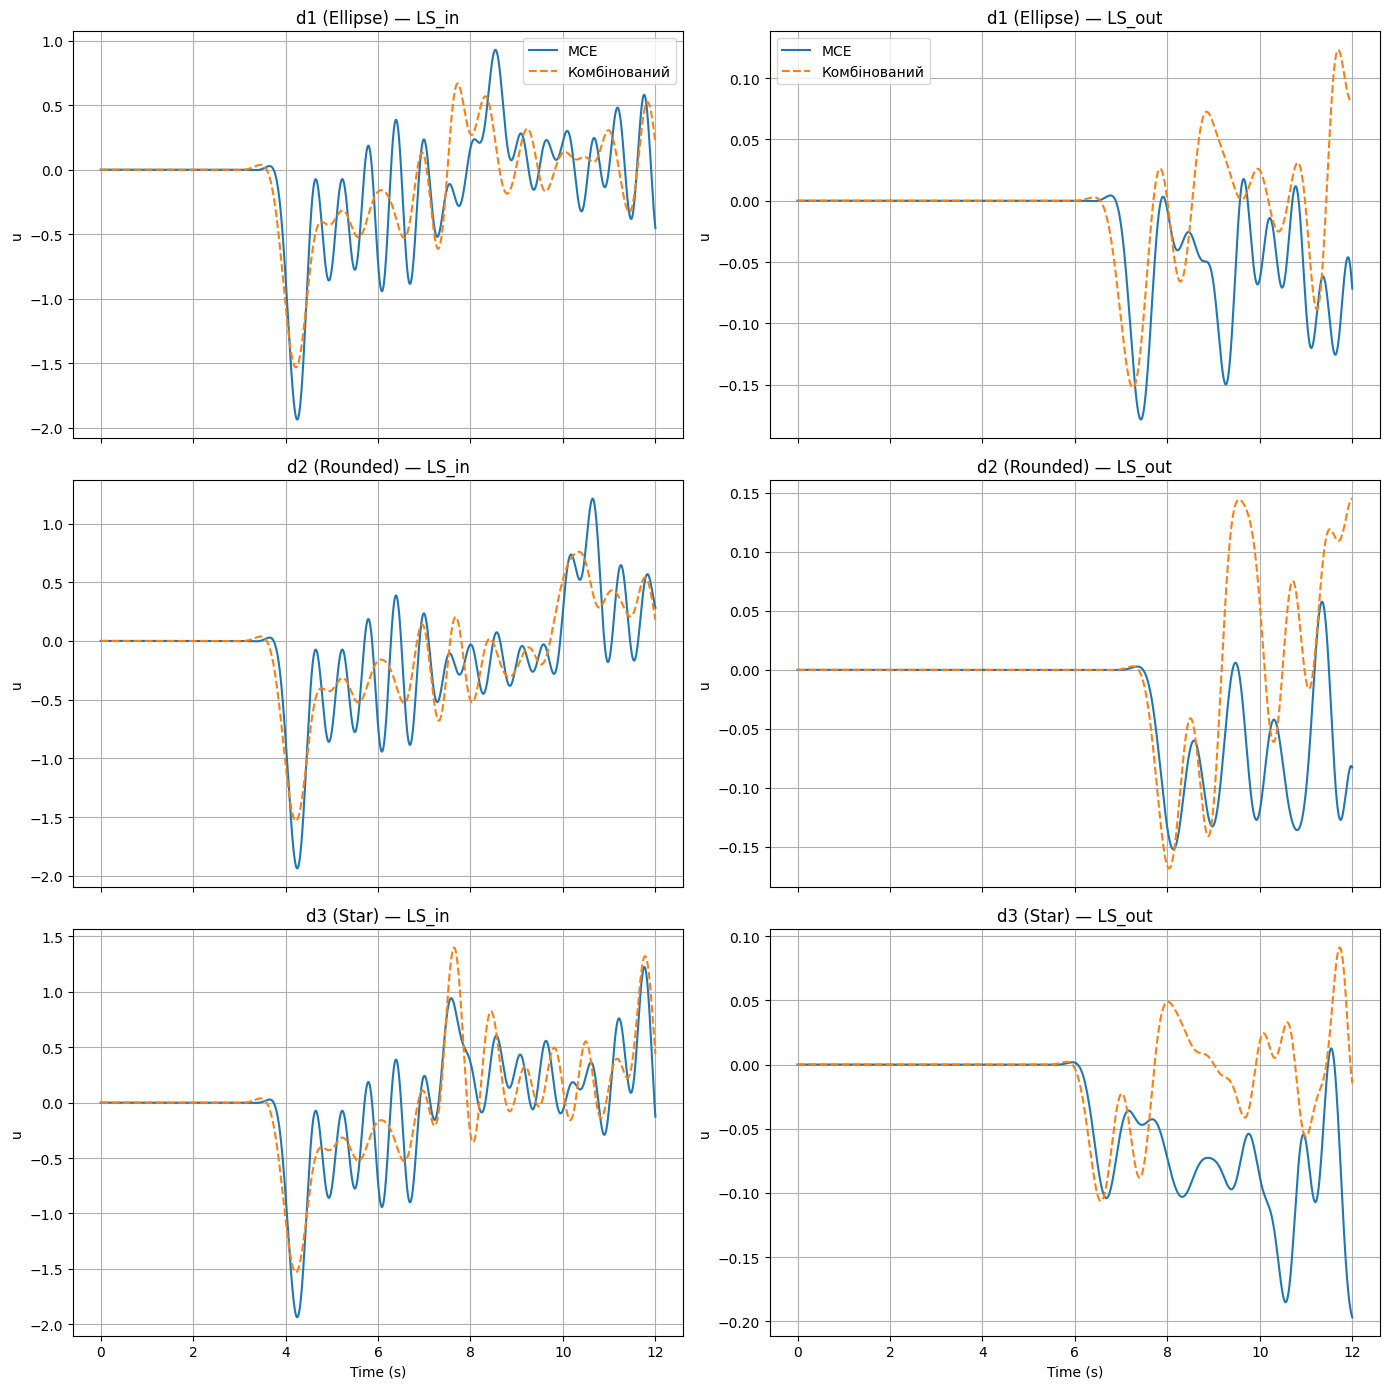

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree
from numba import njit
import time

try:
    import gmsh
except ImportError:
    raise ImportError("Не знайдено gmsh")

def generate_fem_mesh(x0, x1, y0, y1, h):
    if hasattr(gmsh, "isInitialized") and gmsh.isInitialized():
        gmsh.finalize()

    gmsh.initialize()
    gmsh.model.add("fem_rect")

    p1 = gmsh.model.geo.addPoint(x0, y0, 0, h)
    p2 = gmsh.model.geo.addPoint(x1, y0, 0, h)
    p3 = gmsh.model.geo.addPoint(x1, y1, 0, h)
    p4 = gmsh.model.geo.addPoint(x0, y1, 0, h)

    l1 = gmsh.model.geo.addLine(p1, p2)
    l2 = gmsh.model.geo.addLine(p2, p3)
    l3 = gmsh.model.geo.addLine(p3, p4)
    l4 = gmsh.model.geo.addLine(p4, p1)

    loop = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
    gmsh.model.geo.addPlaneSurface([loop])

    nx_pts = int((x1 - x0) / h) + 1
    ny_pts = int((y1 - y0) / h) + 1
    gmsh.model.geo.mesh.setTransfiniteCurve(l1, nx_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l2, ny_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l3, nx_pts)
    gmsh.model.geo.mesh.setTransfiniteCurve(l4, ny_pts)

    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)

    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

    elem_types, elem_tags, elem_node_tags = gmsh.model.mesh.getElements(dim=2)
    elems = None
    for et, tags, nodes_list in zip(elem_types, elem_tags, elem_node_tags):
        if et == 2:
            elems = np.array(nodes_list, dtype=int).reshape(-1, 3)
            break

    if elems is None:
        gmsh.finalize()
        raise RuntimeError("Не знайдено трикутних елементів типу 2.")

    tag_to_idx = {int(tag): i for i, tag in enumerate(node_tags)}
    elems_idx = np.vectorize(tag_to_idx.get)(elems)

    gmsh.finalize()
    return nodes, elems_idx


def create_p2_tilde_mesh(base_nodes, base_elems):
    edge_to_mid = {}
    all_nodes = list(base_nodes.copy())
    p2_elems = np.zeros((len(base_elems), 7), dtype=int)
    centers = []

    for i, tri in enumerate(base_elems):
        v0, v1, v2 = int(tri[0]), int(tri[1]), int(tri[2])
        p2_elems[i, 0:3] = [v0, v1, v2]

        edges = [(v0, v1), (v1, v2), (v2, v0)]
        for j, e in enumerate(edges):
            key = tuple(sorted(e))
            if key not in edge_to_mid:
                mid_coord = 0.5 * (base_nodes[key[0]] + base_nodes[key[1]])
                edge_to_mid[key] = len(all_nodes)
                all_nodes.append(mid_coord)
            p2_elems[i, 3 + j] = edge_to_mid[key]

        center = np.mean(base_nodes[[v0, v1, v2]], axis=0)
        centers.append(center)
        p2_elems[i, 6] = len(all_nodes)
        all_nodes.append(center)

    return np.array(all_nodes), p2_elems, np.array(centers)


def p2_tilde_shape_functions(l1, l2, l3):
    l1l2l3 = l1 * l2 * l3
    N = np.zeros(7, dtype=float)
    N[0] = l1 * (2.0 * l1 - 1.0) + 3.0 * l1l2l3
    N[1] = l2 * (2.0 * l2 - 1.0) + 3.0 * l1l2l3
    N[2] = l3 * (2.0 * l3 - 1.0) + 3.0 * l1l2l3
    N[3] = 4.0 * l1 * l2 - 12.0 * l1l2l3
    N[4] = 4.0 * l2 * l3 - 12.0 * l1l2l3
    N[5] = 4.0 * l3 * l1 - 12.0 * l1l2l3
    N[6] = 27.0 * l1l2l3
    return N


def get_P2_tilde_grad_shape_functions():
    grad_N = [
        lambda l: np.array([4*l[0]-1+3*l[1]*l[2], 3*l[0]*l[2], 3*l[0]*l[1]]),
        lambda l: np.array([3*l[1]*l[2], 4*l[1]-1+3*l[0]*l[2], 3*l[0]*l[1]]),
        lambda l: np.array([3*l[1]*l[2], 3*l[0]*l[2], 4*l[2]-1+3*l[0]*l[1]]),
        lambda l: np.array([4*l[1]-12*l[1]*l[2], 4*l[0]-12*l[0]*l[2], -12*l[0]*l[1]]),
        lambda l: np.array([-12*l[1]*l[2], 4*l[2]-12*l[0]*l[2], 4*l[1]-12*l[0]*l[1]]),
        lambda l: np.array([4*l[2]-12*l[1]*l[2], -12*l[0]*l[2], 4*l[0]-12*l[0]*l[1]]),
        lambda l: np.array([27*l[1]*l[2], 27*l[0]*l[2], 27*l[0]*l[1]])
    ]
    return grad_N


def gauss_quadrature_triangle_p4():
    w1, w2 = 0.223381589678011, 0.109951743655322
    a1, a2 = 0.445948490915965, 0.091576213509771
    pts = np.array([
        [a1, a1],
        [a1, 1 - 2*a1],
        [1 - 2*a1, a1],
        [a2, a2],
        [a2, 1 - 2*a2],
        [1 - 2*a2, a2]
    ])
    wts = np.array([w1, w1, w1, w2, w2, w2])
    return pts, wts


def mass_lumping_weights():
    return np.array([1/20, 1/20, 1/20, 2/15, 2/15, 2/15, 9/20], dtype=float)


def assemble_system(nodes, elems, c_field):
    n_nodes = len(nodes)
    M_diag = np.zeros(n_nodes, dtype=float)

    rows_A, cols_A, data_A = [], [], []
    lump_w = mass_lumping_weights()
    grad_N_funcs = get_P2_tilde_grad_shape_functions()
    quad_pts, quad_wts = gauss_quadrature_triangle_p4()

    for k in range(len(elems)):
        el_nodes = elems[k]
        verts = nodes[el_nodes[0:3]]

        area = 0.5 * abs(
            (verts[1, 0] - verts[0, 0]) * (verts[2, 1] - verts[0, 1]) -
            (verts[1, 1] - verts[0, 1]) * (verts[2, 0] - verts[0, 0])
        )

        for i in range(7):
            M_diag[el_nodes[i]] += area * lump_w[i]

        b = np.array([
            verts[1, 1] - verts[2, 1],
            verts[2, 1] - verts[0, 1],
            verts[0, 1] - verts[1, 1]
        ]) / (2 * area)

        c = np.array([
            verts[2, 0] - verts[1, 0],
            verts[0, 0] - verts[2, 0],
            verts[1, 0] - verts[0, 0]
        ]) / (2 * area)

        grad_lambda = np.array([
            [b[0], c[0]],
            [b[1], c[1]],
            [b[2], c[2]]
        ])

        c_sq = c_field[k]**2
        local_K = np.zeros((7, 7), dtype=float)

        for q in range(len(quad_wts)):
            l1, l2 = quad_pts[q]
            lam = np.array([1 - l1 - l2, l1, l2], dtype=float)
            dNi_dlam = [gn(lam) for gn in grad_N_funcs]

            dNi_dx = np.zeros(7)
            dNi_dy = np.zeros(7)
            for i in range(7):
                grad_xy = dNi_dlam[i] @ grad_lambda
                dNi_dx[i] = grad_xy[0]
                dNi_dy[i] = grad_xy[1]

            factor = quad_wts[q] * area * c_sq
            for i in range(7):
                for j in range(7):
                    local_K[i, j] += (dNi_dx[i]*dNi_dx[j] + dNi_dy[i]*dNi_dy[j]) * factor

        for i in range(7):
            for j in range(7):
                rows_A.append(el_nodes[i])
                cols_A.append(el_nodes[j])
                data_A.append(local_K[i, j])

    A_mat = coo_matrix((data_A, (rows_A, cols_A)), shape=(n_nodes, n_nodes)).tocsr()
    return M_diag, A_mat


def calculate_stable_dt(nodes, elems, c_max, cfl_factor=0.1):
    tri_verts_idx = elems[:, 0:3]
    v0 = nodes[tri_verts_idx[:, 1]] - nodes[tri_verts_idx[:, 0]]
    v1 = nodes[tri_verts_idx[:, 2]] - nodes[tri_verts_idx[:, 1]]
    v2 = nodes[tri_verts_idx[:, 0]] - nodes[tri_verts_idx[:, 2]]
    h_min_global = np.min([
        np.min(np.linalg.norm(v0, axis=1)),
        np.min(np.linalg.norm(v1, axis=1)),
        np.min(np.linalg.norm(v2, axis=1))
    ])
    return cfl_factor * (h_min_global / 2.0) / c_max

def get_basin_radius_polar(theta, n, e, scale=1000.0):
    numerator = 2.0 * (1.0 - e**2)
    denominator = 1.0 - e * np.cos(n * theta)
    return scale * (numerator / denominator)


def set_velocity_field_for_elems(nodes, elems, n, e, c_in, c_out, center):
    elem_centers = np.mean(nodes[elems[:, 0:3]], axis=1)
    dx = elem_centers[:, 0] - center[0]
    dy = elem_centers[:, 1] - center[1]
    r_elem = np.sqrt(dx**2 + dy**2)
    theta_elem = np.arctan2(dy, dx)

    r_boundary = get_basin_radius_polar(theta_elem, n, e, scale=1000.0)

    c_field = np.ones(len(elems)) * c_out
    mask_inside = r_elem < r_boundary
    c_field[mask_inside] = c_in

    return c_field, mask_inside, elem_centers


def build_velocity_grid_constant(x_arr, y_arr, c_value):
    X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')
    return np.ones_like(X) * c_value

def source_func(t, t0=1.0, tau=0.15):
    if t < 0:
        return 0.0
    val = (t - t0) / (tau**2) * np.exp(-(t - t0) / tau)
    return val if val > -100 else 0.0


def interp_on_grid(field, x, y, dx, dy):
    i0 = min(max(int(np.floor(x / dx)), 0), field.shape[0] - 2)
    j0 = min(max(int(np.floor(y / dy)), 0), field.shape[1] - 2)
    wx = x / dx - i0
    wy = y / dy - j0
    return (
        (1 - wx) * (1 - wy) * field[i0,     j0    ] +
        wx       * (1 - wy) * field[i0 + 1, j0    ] +
        (1 - wx) * wy       * field[i0,     j0 + 1] +
        wx       * wy       * field[i0 + 1, j0 + 1]
    )

@njit
def update_fdm_constant_c(u, u_old, c_grid, dx, dy, dt):
    nx, ny = u.shape
    u_new = np.zeros_like(u)
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            lap = ((u[i + 1, j] - 2.0*u[i, j] + u[i - 1, j]) / dx**2 +
                   (u[i, j + 1] - 2.0*u[i, j] + u[i, j - 1]) / dy**2)
            u_new[i, j] = 2.0*u[i, j] - u_old[i, j] + dt**2 * (c_grid[i, j]**2) * lap
    return u_new

def build_exact_fem_to_grid_matrix(base_nodes, base_elems, p2_elems, x_arr, y_arr, n_fem_nodes):
    triang = mtri.Triangulation(base_nodes[:, 0], base_nodes[:, 1], base_elems)
    finder = triang.get_trifinder()

    rows, cols, data = [], [], []
    Nx_loc = len(x_arr)
    Ny_loc = len(y_arr)

    for i in range(Nx_loc):
        for j in range(Ny_loc):
            x, y = x_arr[i], y_arr[j]
            tri_idx = finder(x, y)
            if tri_idx != -1:
                tri = base_elems[tri_idx]
                x1, y1 = base_nodes[tri[0]]
                x2, y2 = base_nodes[tri[1]]
                x3, y3 = base_nodes[tri[2]]

                detT = (y2 - y3)*(x1 - x3) + (x3 - x2)*(y1 - y3)
                l1 = ((y2 - y3)*(x - x3) + (x3 - x2)*(y - y3)) / detT
                l2 = ((y3 - y1)*(x - x3) + (x1 - x3)*(y - y3)) / detT
                l3 = 1.0 - l1 - l2

                N = p2_tilde_shape_functions(l1, l2, l3)
                fem_nodes_idx = p2_elems[tri_idx]
                flat_idx = i * Ny_loc + j

                for k in range(7):
                    rows.append(flat_idx)
                    cols.append(fem_nodes_idx[k])
                    data.append(N[k])

    P = coo_matrix((data, (rows, cols)), shape=(Nx_loc * Ny_loc, n_fem_nodes)).tocsr()
    return P, triang, finder

# ПАРАМЕТРИ ЗАДАЧІ
L_domain = 10000.0
c_out = 1700.0
c_in = 300.0

center_pos = (5000.0, 5000.0)
source_pos = (5000.0, 5000.0)
rec_in_pos = (5000.0, 6000.0)
rec_out_pos = (5000.0, 8500.0)

shapes = {
    'd1 (Ellipse)': {'n': 2, 'e': 0.2},
    'd2 (Rounded)': {'n': 4, 'e': 0.15},
    'd3 (Star)':    {'n': 4, 'e': 0.4}
}

T_max = 12.0

mesh_h_full = 130.0
base_nodes_full, base_elems_full = generate_fem_mesh(0.0, L_domain, 0.0, L_domain, mesh_h_full)
all_nodes_full, p2_elems_full, fem_centers_full = create_p2_tilde_mesh(base_nodes_full, base_elems_full)
n_nodes_full = len(all_nodes_full)
print(f"МСЕ: {n_nodes_full} вузлів.")

dt_full = calculate_stable_dt(all_nodes_full, p2_elems_full, c_out, cfl_factor=0.1)

tree_full = KDTree(all_nodes_full)
_, idx_S_full = tree_full.query(source_pos)
_, idx_Lin_full = tree_full.query(rec_in_pos)
_, idx_Lout_full = tree_full.query(rec_out_pos)

Nx_h, Ny_h = 101, 101
dx_h = L_domain / (Nx_h - 1)
dy_h = L_domain / (Ny_h - 1)
x_fdm_h = np.linspace(0.0, L_domain, Nx_h)
y_fdm_h = np.linspace(0.0, L_domain, Ny_h)

x_min_h, x_max_h = 2200.0, 7800.0
y_min_h, y_max_h = 2200.0, 9000.0

mesh_h_local = 150.0

base_nodes_h, base_elems_h = generate_fem_mesh(x_min_h, x_max_h, y_min_h, y_max_h, mesh_h_local)
all_nodes_h, p2_elems_h, fem_centers_h = create_p2_tilde_mesh(base_nodes_h, base_elems_h)
n_nodes_h = len(all_nodes_h)
print(f"Комбінований метод, МСЕ: {n_nodes_h} вузлів.")

dt_hyb = calculate_stable_dt(all_nodes_h, p2_elems_h, c_out, cfl_factor=0.1)

dt = min(dt_full, dt_hyb, 0.05 * dx_h / c_out)
n_steps = int(T_max / dt)
t_arr = np.linspace(0.0, T_max, n_steps)
source_vals = np.array([source_func(t) * 1e5 for t in t_arr])

c_grid_h = build_velocity_grid_constant(x_fdm_h, y_fdm_h, c_out)

P_fem_to_fdm_h, triang_h, finder_h = build_exact_fem_to_grid_matrix(
    base_nodes_h, base_elems_h, p2_elems_h, x_fdm_h, y_fdm_h, n_nodes_h
)

i0_arr_h = np.clip(np.floor(all_nodes_h[:, 0] / dx_h).astype(int), 0, Nx_h - 2)
j0_arr_h = np.clip(np.floor(all_nodes_h[:, 1] / dy_h).astype(int), 0, Ny_h - 2)
wx_arr_h = (all_nodes_h[:, 0] / dx_h) - i0_arr_h
wy_arr_h = (all_nodes_h[:, 1] / dy_h) - j0_arr_h

def interpolate_fdm_to_fem_h(u_fdm):
    return (
        (1 - wx_arr_h) * (1 - wy_arr_h) * u_fdm[i0_arr_h,     j0_arr_h    ] +
        wx_arr_h       * (1 - wy_arr_h) * u_fdm[i0_arr_h + 1, j0_arr_h    ] +
        (1 - wx_arr_h) * wy_arr_h       * u_fdm[i0_arr_h,     j0_arr_h + 1] +
        wx_arr_h       * wy_arr_h       * u_fdm[i0_arr_h + 1, j0_arr_h + 1]
    )

feb_width = 1.0 * dx_h
avg_width = 3.0 * dx_h
fdd_width = 1.0 * dx_h
transition_width = feb_width + avg_width + fdd_width

def inside_fem_rect_h(x, y):
    return (x_min_h <= x <= x_max_h) and (y_min_h <= y <= y_max_h)

def dist_to_fem_boundary_h(x, y):
    return min(x - x_min_h, x_max_h - x, y - y_min_h, y_max_h - y)

mask_inside_fem_fdm_h = np.zeros((Nx_h, Ny_h), dtype=bool)
mask_avg_fdm_h = np.zeros((Nx_h, Ny_h), dtype=bool)
mask_fdd_fdm_h = np.zeros((Nx_h, Ny_h), dtype=bool)
w_avg_fdm_h = np.zeros((Nx_h, Ny_h), dtype=float)

for i in range(Nx_h):
    for j in range(Ny_h):
        x, y = x_fdm_h[i], y_fdm_h[j]
        if inside_fem_rect_h(x, y):
            mask_inside_fem_fdm_h[i, j] = True
            d = dist_to_fem_boundary_h(x, y)
            if feb_width <= d < feb_width + avg_width:
                mask_avg_fdm_h[i, j] = True
                w_avg_fdm_h[i, j] = (d - feb_width) / avg_width
            elif feb_width + avg_width <= d < transition_width:
                mask_fdd_fdm_h[i, j] = True

mask_feb_fem_h = np.zeros(n_nodes_h, dtype=bool)
mask_avg_fem_h = np.zeros(n_nodes_h, dtype=bool)
w_avg_fem_h = np.zeros(n_nodes_h, dtype=float)

for k, (x, y) in enumerate(all_nodes_h):
    d = dist_to_fem_boundary_h(x, y)
    if d < feb_width:
        mask_feb_fem_h[k] = True
    elif feb_width <= d < feb_width + avg_width:
        mask_avg_fem_h[k] = True
        w_avg_fem_h[k] = (d - feb_width) / avg_width

tree_local = KDTree(all_nodes_h)
_, idx_S_local = tree_local.query(source_pos)

results = {}

for name, params in shapes.items():
    print(f"\nОбчислення для {name}")

    c_field_full, mask_full, centers_full = set_velocity_field_for_elems(
        all_nodes_full, p2_elems_full, params['n'], params['e'], c_in, c_out, center_pos
    )

    M_full, K_full = assemble_system(all_nodes_full, p2_elems_full, c_field_full)
    inv_M_full = 1.0 / M_full

    u_prev_full = np.zeros(n_nodes_full)
    u_curr_full = np.zeros(n_nodes_full)

    hist_full_in = []
    hist_full_out = []

    t0 = time.time()
    for n in range(n_steps):
        F_vec = np.zeros(n_nodes_full)
        F_vec[idx_S_full] = source_vals[n]

        Ku = K_full.dot(u_curr_full)
        accel = (F_vec - Ku) * inv_M_full
        u_next = 2.0 * u_curr_full - u_prev_full + (dt**2) * accel

        hist_full_in.append(u_next[idx_Lin_full])
        hist_full_out.append(u_next[idx_Lout_full])

        u_prev_full[:] = u_curr_full[:]
        u_curr_full[:] = u_next[:]

    fem_time = time.time() - t0

    c_field_h, mask_h, centers_h = set_velocity_field_for_elems(
        all_nodes_h, p2_elems_h, params['n'], params['e'], c_in, c_out, center_pos
    )

    M_h, K_h = assemble_system(all_nodes_h, p2_elems_h, c_field_h)
    inv_M_h = 1.0 / M_h

    u_prev_fdm = np.zeros((Nx_h, Ny_h))
    u_curr_fdm = np.zeros((Nx_h, Ny_h))

    u_prev_fem = np.zeros(n_nodes_h)
    u_curr_fem = np.zeros(n_nodes_h)

    hist_hyb_in = []
    hist_hyb_out = []

    t1 = time.time()
    for n in range(n_steps):
        u_next_fdm_star = update_fdm_constant_c(u_curr_fdm, u_prev_fdm, c_grid_h, dx_h, dy_h, dt)

        F_local = np.zeros(n_nodes_h)
        F_local[idx_S_local] = source_vals[n]

        Ku_h = K_h.dot(u_curr_fem)
        accel_h = (F_local - Ku_h) * inv_M_h
        u_next_fem_star = 2.0 * u_curr_fem - u_prev_fem + dt**2 * accel_h

        u_fem_at_fdm = P_fem_to_fdm_h.dot(u_next_fem_star).reshape(Nx_h, Ny_h)
        u_fdm_at_fem = interpolate_fdm_to_fem_h(u_next_fdm_star)

        u_next_fdm = u_next_fdm_star.copy()
        u_next_fem = u_next_fem_star.copy()

        u_next_fdm[mask_fdd_fdm_h] = u_fem_at_fdm[mask_fdd_fdm_h]

        u_next_fdm[mask_avg_fdm_h] = (
            (1.0 - w_avg_fdm_h[mask_avg_fdm_h]) * u_next_fdm_star[mask_avg_fdm_h] +
            w_avg_fdm_h[mask_avg_fdm_h]         * u_fem_at_fdm[mask_avg_fdm_h]
        )

        u_next_fem[mask_feb_fem_h] = u_fdm_at_fem[mask_feb_fem_h]

        u_next_fem[mask_avg_fem_h] = (
            w_avg_fem_h[mask_avg_fem_h]         * u_next_fem_star[mask_avg_fem_h] +
            (1.0 - w_avg_fem_h[mask_avg_fem_h]) * u_fdm_at_fem[mask_avg_fem_h]
        )

        hybrid_field = u_next_fdm.copy()
        hybrid_field[mask_inside_fem_fdm_h] = u_fem_at_fdm[mask_inside_fem_fdm_h]

        hist_hyb_in.append(interp_on_grid(hybrid_field, rec_in_pos[0], rec_in_pos[1], dx_h, dy_h))
        hist_hyb_out.append(interp_on_grid(hybrid_field, rec_out_pos[0], rec_out_pos[1], dx_h, dy_h))

        u_prev_fdm[:] = u_curr_fdm[:]
        u_curr_fdm[:] = u_next_fdm[:]

        u_prev_fem[:] = u_curr_fem[:]
        u_curr_fem[:] = u_next_fem[:]

    hyb_time = time.time() - t1

    print(f"  МСЕ: {fem_time:.2f} с")
    print(f"  Комбінований: {hyb_time:.2f} с")

    results[name] = {
        'centers': centers_full,
        'mask': mask_full,
        'fem_in': hist_full_in,
        'fem_out': hist_full_out,
        'hyb_in': hist_hyb_in,
        'hyb_out': hist_hyb_out
    }

plt.figure(figsize=(18, 6))
for i, (name, data) in enumerate(results.items()):
    plt.subplot(1, 3, i + 1)

    centers = data['centers']
    mask = data['mask']

    plt.scatter(centers[~mask, 0], centers[~mask, 1], c='whitesmoke', s=1, edgecolor='none')
    plt.scatter(centers[mask, 0], centers[mask, 1], c='teal', s=2, alpha=0.75, label='Осадовий басейн (c = 300.0 м/с)')

    rect = plt.Rectangle((x_min_h, y_min_h), x_max_h - x_min_h, y_max_h - y_min_h,
                         edgecolor='white', facecolor='none', linestyle='--', linewidth=1.5)
    plt.gca().add_patch(rect)

    plt.plot(source_pos[0], source_pos[1], 'ko', markersize=12, label='Джерело')
    plt.plot(rec_in_pos[0], rec_in_pos[1], 'ro', markersize=8, label='LS_in')
    plt.plot(rec_out_pos[0], rec_out_pos[1], 'bo', markersize=8, label='LS_out')

    plt.title(name)
    plt.axis('equal')
    if i == 0:
        plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)

for row, (name, data) in enumerate(results.items()):
    ax = axes[row, 0]
    ax.plot(t_arr, data['fem_in'], label='МСЕ', linewidth=1.5)
    ax.plot(t_arr, data['hyb_in'], label='Комбінований', linewidth=1.5, linestyle='--')
    ax.set_title(f"{name} — LS_in")
    ax.set_ylabel("u")
    ax.grid(True)
    if row == 0:
        ax.legend()

    ax = axes[row, 1]
    ax.plot(t_arr, data['fem_out'], label='МСЕ', linewidth=1.5)
    ax.plot(t_arr, data['hyb_out'], label='Комбінований', linewidth=1.5, linestyle='--')
    ax.set_title(f"{name} — LS_out")
    ax.set_ylabel("u")
    ax.grid(True)
    if row == 0:
        ax.legend()

axes[2, 0].set_xlabel("Time (s)")
axes[2, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()